In [1]:
import geopandas as gpd
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"GeoPandas version: {gpd.__version__}")
print(f"Pandas version: {pd.__version__}")


Libraries imported successfully!
GeoPandas version: 1.0.1
Pandas version: 2.2.3


In [2]:
# Define paths
base_dir = Path(".")
parcel_dir = base_dir / "stratmap25-landparcels_48201_lp" / "shp"
texas_geojson_path = base_dir / "Texas.geojson"

print("Data paths:")
print(f"Parcel directory: {parcel_dir}")
print(f"Texas GeoJSON: {texas_geojson_path}")
print(f"Parcel directory exists: {parcel_dir.exists()}")
print(f"Texas GeoJSON exists: {texas_geojson_path.exists()}")

# List parcel shapefiles
if parcel_dir.exists():
    shp_files = list(parcel_dir.glob("*.shp"))
    print(f"\nFound {len(shp_files)} shapefile(s):")
    for shp in shp_files:
        print(f"  - {shp.name}")
else:
    print("Parcel directory not found!")


Data paths:
Parcel directory: stratmap25-landparcels_48201_lp/shp
Texas GeoJSON: Texas.geojson
Parcel directory exists: True
Texas GeoJSON exists: True

Found 2 shapefile(s):
  - stratmap25-landparcels_48201_harris_west_202508.shp
  - stratmap25-landparcels_48201_harris_east_202508.shp


In [3]:
# Read Harris County parcel data (both east and west)
print("Reading Harris County parcel data...")

parcel_gdfs = []
shp_files = list(parcel_dir.glob("*.shp"))

for shp_file in shp_files:
    print(f"\nReading: {shp_file.name}")
    try:
        gdf = gpd.read_file(shp_file)
        print(f"  Shape: {gdf.shape}")
        print(f"  CRS: {gdf.crs}")
        print(f"  Columns: {list(gdf.columns[:5])}{'...' if len(gdf.columns) > 5 else ''}")
        parcel_gdfs.append(gdf)
    except Exception as e:
        print(f"  Error reading {shp_file.name}: {e}")

# Combine east and west Harris County parcels
if parcel_gdfs:
    print(f"\nCombining {len(parcel_gdfs)} parcel datasets...")
    harris_parcels = gpd.GeoDataFrame(pd.concat(parcel_gdfs, ignore_index=True))
    harris_parcels.crs = parcel_gdfs[0].crs  # Ensure CRS is preserved
    
    print(f"Combined Harris County parcels:")
    print(f"  Total parcels: {len(harris_parcels):,}")
    print(f"  CRS: {harris_parcels.crs}")
    print(f"  Bounds: {harris_parcels.total_bounds}")
    print(f"  Columns: {list(harris_parcels.columns)}")
else:
    print("No parcel data loaded!")
    harris_parcels = None


Reading Harris County parcel data...

Reading: stratmap25-landparcels_48201_harris_west_202508.shp
  Shape: (987129, 37)
  CRS: EPSG:4326
  Columns: ['Prop_ID', 'GEO_ID', 'OWNER_NAME', 'NAME_CARE', 'LEGAL_AREA']...

Reading: stratmap25-landparcels_48201_harris_east_202508.shp
  Shape: (536512, 37)
  CRS: EPSG:4326
  Columns: ['Prop_ID', 'GEO_ID', 'OWNER_NAME', 'NAME_CARE', 'LEGAL_AREA']...

Combining 2 parcel datasets...
Combined Harris County parcels:
  Total parcels: 1,523,641
  CRS: EPSG:4326
  Bounds: [-95.96082689  29.4973017  -94.90761062  30.17054931]
  Columns: ['Prop_ID', 'GEO_ID', 'OWNER_NAME', 'NAME_CARE', 'LEGAL_AREA', 'LGL_AREA_U', 'GIS_AREA', 'GIS_AREA_U', 'LEGAL_DESC', 'STAT_LAND_', 'LOC_LAND_U', 'LAND_VALUE', 'IMP_VALUE', 'MKT_VALUE', 'SITUS_ADDR', 'SITUS_NUM', 'SITUS_STRE', 'SITUS_ST_1', 'SITUS_ST_2', 'SITUS_CITY', 'SITUS_STAT', 'SITUS_ZIP', 'MAIL_ADDR', 'MAIL_LINE1', 'MAIL_LINE2', 'MAIL_CITY', 'MAIL_STAT', 'MAIL_ZIP', 'SOURCE', 'DATE_ACQ', 'FIPS', 'COUNTY', 'TAX_YEAR'

In [4]:
harris_parcels.columns

Index(['Prop_ID', 'GEO_ID', 'OWNER_NAME', 'NAME_CARE', 'LEGAL_AREA',
       'LGL_AREA_U', 'GIS_AREA', 'GIS_AREA_U', 'LEGAL_DESC', 'STAT_LAND_',
       'LOC_LAND_U', 'LAND_VALUE', 'IMP_VALUE', 'MKT_VALUE', 'SITUS_ADDR',
       'SITUS_NUM', 'SITUS_STRE', 'SITUS_ST_1', 'SITUS_ST_2', 'SITUS_CITY',
       'SITUS_STAT', 'SITUS_ZIP', 'MAIL_ADDR', 'MAIL_LINE1', 'MAIL_LINE2',
       'MAIL_CITY', 'MAIL_STAT', 'MAIL_ZIP', 'SOURCE', 'DATE_ACQ', 'FIPS',
       'COUNTY', 'TAX_YEAR', 'YEAR_BUILT', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='object')

In [5]:
# Read Texas.geojson (building polygon data)
print("Reading Texas.geojson building polygon data...")

try:
    texas_buildings = gpd.read_file(texas_geojson_path)
    print(f"Texas buildings loaded successfully!")
    print(f"  Total buildings: {len(texas_buildings):,}")
    print(f"  CRS: {texas_buildings.crs}")
    print(f"  Bounds: {texas_buildings.total_bounds}")
    print(f"  Columns: {list(texas_buildings.columns)}")
    
    # Show sample of data
    print(f"\nFirst 5 rows:")
    print(texas_buildings.head())
    
    # Check for county information
    county_cols = [col for col in texas_buildings.columns if 'county' in col.lower() or 'fips' in col.lower()]
    print(f"\nPotential county identifier columns: {county_cols}")
    
    if county_cols:
        for col in county_cols:
            unique_vals = texas_buildings[col].unique()[:10]  # Show first 10 unique values
            print(f"  {col}: {unique_vals} (showing first 10)")
    
except Exception as e:
    print(f"Error reading Texas.geojson: {e}")
    texas_buildings = None


Reading Texas.geojson building polygon data...
Texas buildings loaded successfully!
  Total buildings: 10,678,921
  CRS: EPSG:4326
  Bounds: [-106.651118   25.832813  -93.51509    36.504452]
  Columns: ['release', 'capture_dates_range', 'geometry']

First 5 rows:
   release  capture_dates_range  \
0        1                        
1        2  4/23/2020-4/25/2020   
2        1                        
3        1                        
4        1                        

                                            geometry  
0  POLYGON ((-96.56063 32.83467, -96.56057 32.834...  
1  POLYGON ((-96.56068 28.67777, -96.56079 28.677...  
2  POLYGON ((-96.56073 33.256, -96.56065 33.256, ...  
3  POLYGON ((-96.56079 32.98237, -96.56079 32.982...  
4  POLYGON ((-96.56085 33.48873, -96.56079 33.488...  

Potential county identifier columns: []


In [6]:
texas_buildings

,release,capture_dates_range,geometry
0,1,,"POLYGON ((-96.56063 32.83467, -96.56057 32.834..."
1,2,4/23/2020-4/25/2020,"POLYGON ((-96.56068 28.67777, -96.56079 28.677..."
2,1,,"POLYGON ((-96.56073 33.256, -96.56065 33.256, ..."
3,1,,"POLYGON ((-96.56079 32.98237, -96.56079 32.982..."
4,1,,"POLYGON ((-96.56085 33.48873, -96.56079 33.488..."
...,...,...,...
10678916,2,1/18/2020-11/15/2020,"POLYGON ((-96.60022 32.8234, -96.60029 32.8232..."
10678917,2,1/18/2020-11/15/2020,"POLYGON ((-96.60023 32.82047, -96.60038 32.820..."
10678918,1,,"POLYGON ((-96.60029 32.97534, -96.60016 32.975..."
10678919,2,12/14/2019-12/18/2019,"POLYGON ((-96.60032 30.18532, -96.60014 30.185..."


In [ ]:
def get_harris_county_boundary(harris_parcels):
    """
    Get Harris County boundary efficiently using pygris or fallback to parcel union.
    """
    # Check for pygris availability within the function
    try:
        from pygris import counties
        print("    Getting Harris County boundary from pygris...")
        
        # Download Harris County boundary from Census TIGER/Line
        # pygris counties() function parameters: state, year, cb (for cartographic boundary)
        harris_county_boundary = counties(state="TX", year=2022, cb=True)
        
        # Filter to Harris County (FIPS code 201)
        harris_county_boundary = harris_county_boundary[harris_county_boundary['COUNTYFP'] == '201']
        
        if len(harris_county_boundary) == 0:
            raise ValueError("Harris County not found in pygris counties data")
        
        # Ensure same CRS as parcels
        if harris_county_boundary.crs != harris_parcels.crs:
            harris_county_boundary = harris_county_boundary.to_crs(harris_parcels.crs)
        
        # Extract the geometry (should be a single polygon)
        boundary_geom = harris_county_boundary.geometry.iloc[0]
        print(f"    ✓ Retrieved Harris County boundary from pygris")
        return boundary_geom
        
    except ImportError:
        print("    ⚠ pygris not available, using parcel union...")
    except Exception as e:
        print(f"    ⚠ pygris failed ({e}), falling back to parcel union...")
    
    # Fallback: compute union of parcels (slower but reliable)
    print("    Computing Harris County boundary from parcel union...")
    boundary_geom = harris_parcels.unary_union
    print(f"    ✓ Computed boundary from {len(harris_parcels):,} parcels")
    return boundary_geom

# Filter Texas buildings for Harris County
print("Filtering Texas buildings for Harris County...")

if texas_buildings is not None and harris_parcels is not None:
    # Method 1: Try filtering by county FIPS code (48201 for Harris County)
    harris_buildings = None
    
    # Check for FIPS code columns
    fips_cols = [col for col in texas_buildings.columns if 'fips' in col.lower() or 'geoid' in col.lower()]
    
    if fips_cols:
        for col in fips_cols:
            print(f"Trying to filter by {col}...")
            # Harris County FIPS code is 48201
            harris_filter = texas_buildings[col].astype(str).str.contains('48201', na=False)
            if harris_filter.any():
                harris_buildings = texas_buildings[harris_filter].copy()
                print(f"  Found {len(harris_buildings):,} buildings using {col}")
                break
    
    # Method 2: If no FIPS filtering worked, try optimized spatial filtering
    if harris_buildings is None or len(harris_buildings) == 0:
        print("No FIPS-based filtering successful. Trying optimized spatial filtering...")
        
        # Ensure both datasets have the same CRS
        if texas_buildings.crs != harris_parcels.crs:
            print(f"Reprojecting Texas buildings from {texas_buildings.crs} to {harris_parcels.crs}")
            texas_buildings_proj = texas_buildings.to_crs(harris_parcels.crs)
        else:
            texas_buildings_proj = texas_buildings
        
        # Step 1: Fast bounding box pre-filtering
        print("  Step 1: Applying bounding box filter...")
        harris_bounds = harris_parcels.total_bounds
        print(f"    Harris County bounds: {harris_bounds}")
        
        # Get building bounds efficiently
        building_bounds = texas_buildings_proj.geometry.bounds
        
        # Apply bounding box filter
        bbox_filter = (
            (building_bounds.minx <= harris_bounds[2]) &  # building left edge <= county right edge
            (building_bounds.maxx >= harris_bounds[0]) &  # building right edge >= county left edge
            (building_bounds.miny <= harris_bounds[3]) &  # building bottom edge <= county top edge
            (building_bounds.maxy >= harris_bounds[1])    # building top edge >= county bottom edge
        )
        
        bbox_candidates = texas_buildings_proj[bbox_filter].copy()
        print(f"    Bounding box filter: {len(bbox_candidates):,} candidate buildings (from {len(texas_buildings_proj):,})")
        
        if len(bbox_candidates) > 0:
            # Step 2: Precise centroid-based filtering on candidates only
            print("  Step 2: Applying centroid-based spatial filter...")
            
            # Get Harris County boundary efficiently
            harris_boundary = get_harris_county_boundary(harris_parcels)
            
            # Calculate centroids for candidates only
            candidate_centroids = bbox_candidates.geometry.centroid
            
            # Point-in-polygon test (much faster than polygon intersection)
            within_filter = candidate_centroids.within(harris_boundary)
            
            harris_buildings = bbox_candidates[within_filter].copy()
            print(f"    Centroid filter: {len(harris_buildings):,} buildings within Harris County")
        else:
            harris_buildings = gpd.GeoDataFrame(columns=texas_buildings_proj.columns, crs=texas_buildings_proj.crs)
            print("    No buildings found within bounding box")
    
    # Method 3: Alternative - check for county name columns
    if harris_buildings is None or len(harris_buildings) == 0:
        county_name_cols = [col for col in texas_buildings.columns if 'county' in col.lower() and 'name' in col.lower()]
        if county_name_cols:
            for col in county_name_cols:
                harris_filter = texas_buildings[col].astype(str).str.contains('Harris', case=False, na=False)
                if harris_filter.any():
                    harris_buildings = texas_buildings[harris_filter].copy()
                    print(f"  Found {len(harris_buildings):,} buildings using county name filter on {col}")
                    break
    
    if harris_buildings is not None and len(harris_buildings) > 0:
        print(f"\nHarris County buildings successfully filtered!")
        print(f"  Total Harris County buildings: {len(harris_buildings):,}")
        print(f"  CRS: {harris_buildings.crs}")
        print(f"  Bounds: {harris_buildings.total_bounds}")
        
        # Show sample
        print(f"\nSample of Harris County buildings:")
        print(harris_buildings.head())
    else:
        print("Could not filter buildings for Harris County. Check the data structure.")
        harris_buildings = None
        
else:
    print("Cannot filter - missing Texas buildings or Harris parcels data")
    harris_buildings = None


Filtering Texas buildings for Harris County...
No FIPS-based filtering successful. Trying optimized spatial filtering...
  Step 1: Applying bounding box filter...
    Harris County bounds: [-95.96082689  29.4973017  -94.90761062  30.17054931]
    Bounding box filter: 1,805,303 candidate buildings (from 10,678,921)
  Step 2: Applying centroid-based spatial filter...
    Getting Harris County boundary from pygris...
Using FIPS code '48' for input 'TX'
    ✓ Retrieved Harris County boundary from pygris


# Building Population Estimation Workflow for Harris County

This notebook implements a comprehensive 6-phase workflow to estimate people per building in Harris County using:
- Harris County parcel data with property classifications
- Texas building footprint polygons 
- US Census ACS demographic data at the Census Block Group level

## Workflow Overview:
1. **Phase 1**: Data Preparation and Preprocessing
2. **Phase 2**: Building Classification 
3. **Phase 3**: Census Data Integration
4. **Phase 4**: Population Assignment
5. **Phase 5**: Quality Control and Validation
6. **Phase 6**: Final Output and Documentation


## Phase 1: Data Preparation and Preprocessing

### Step 1.1: Prepare Building Footprint Data
- Clean geometry and calculate footprint areas
- Calculate shape metrics (aspect ratio, perimeter-to-area ratio, compactness)
- Assign unique building IDs

### Step 1.2: Prepare Parcel Data  
- Filter to residential parcels
- Clean parcel classifications
- Calculate parcel metrics

### Step 1.3: Spatial Integration
- Spatial join buildings to parcels
- Geocode to census geographies


In [ ]:
# Additional imports for the population estimation workflow
import numpy as np
from shapely.geometry import Point, Polygon
from shapely.validation import make_valid
from shapely.ops import unary_union
import math
import requests
import time
from urllib.parse import urlencode

# For census data
try:
    import cenpy
    print("cenpy available for census data")
except ImportError:
    print("cenpy not available - will use alternative method for census data")
    cenpy = None

print("Additional libraries imported successfully!")


cenpy not available - will use alternative method for census data
Additional libraries imported successfully!


In [ ]:
# BUILDING-LEVEL POPULATION ESTIMATION SYSTEM FOR HARRIS COUNTY
# ================================================================

print("Starting Building-Level Population Estimation System Implementation")
print("=" * 70)

# Additional imports needed for the complete implementation
import requests
import json
from urllib.parse import urlencode
import random
from datetime import datetime
import seaborn as sns
from matplotlib.patches import Patch
import folium
from folium import plugins
import warnings
warnings.filterwarnings('ignore')

# Import pygris for efficient county boundary retrieval
try:
    from pygris import counties
    print("✓ pygris available for county boundaries")
    PYGRIS_AVAILABLE = True
except ImportError:
    print("⚠ pygris not available - will use parcel union fallback")
    PYGRIS_AVAILABLE = False

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

print("✓ All required libraries imported successfully!")
print("✓ Random seed set for reproducible results")


Starting Building-Level Population Estimation System Implementation
✓ pygris available for county boundaries
✓ All required libraries imported successfully!
✓ Random seed set for reproducible results


In [ ]:
# STEP 1: SUBSET TO SMALL TEST AREA
# =================================

def select_random_test_area(buildings_gdf, parcels_gdf, target_building_count=3000):
    """
    Select a random test area with approximately target_building_count buildings.
    Uses a grid-based approach to find a suitable rectangular area.
    """
    print(f"Selecting test area with ~{target_building_count:,} buildings...")
    
    # Get bounds of the data
    bounds = buildings_gdf.total_bounds
    min_x, min_y, max_x, max_y = bounds
    
    # Create a grid of potential test areas
    grid_size = 20  # 20x20 grid
    x_step = (max_x - min_x) / grid_size
    y_step = (max_y - min_y) / grid_size
    
    best_area = None
    best_count = 0
    best_bounds = None
    
    # Try different rectangular areas
    for i in range(50):  # Try 50 random areas
        # Random starting point
        start_x = min_x + random.random() * (max_x - min_x - 2*x_step)
        start_y = min_y + random.random() * (max_y - min_y - 2*y_step)
        
        # Random size (1-4 grid cells in each direction)
        width = x_step * (1 + random.random() * 3)
        height = y_step * (1 + random.random() * 3)
        
        test_bounds = [start_x, start_y, start_x + width, start_y + height]
        
        # Count buildings in this area
        mask = ((buildings_gdf.geometry.bounds.minx >= test_bounds[0]) &
                (buildings_gdf.geometry.bounds.miny >= test_bounds[1]) &
                (buildings_gdf.geometry.bounds.maxx <= test_bounds[2]) &
                (buildings_gdf.geometry.bounds.maxy <= test_bounds[3]))
        
        count = mask.sum()
        
        # Check if this is closer to our target
        if abs(count - target_building_count) < abs(best_count - target_building_count):
            best_count = count
            best_bounds = test_bounds
    
    if best_bounds is None:
        print("Could not find suitable test area, using first 3000 buildings")
        return buildings_gdf.head(3000), parcels_gdf.head(10000)
    
    # Filter data to the best test area
    building_mask = ((buildings_gdf.geometry.bounds.minx >= best_bounds[0]) &
                     (buildings_gdf.geometry.bounds.miny >= best_bounds[1]) &
                     (buildings_gdf.geometry.bounds.maxx <= best_bounds[2]) &
                     (buildings_gdf.geometry.bounds.maxy <= best_bounds[3]))
    
    test_buildings = buildings_gdf[building_mask].copy()
    
    # Get parcels that intersect with the test area
    parcel_mask = parcels_gdf.geometry.bounds.apply(
        lambda x: (x.minx < best_bounds[2] and x.maxx > best_bounds[0] and
                   x.miny < best_bounds[3] and x.maxy > best_bounds[1]), axis=1)
    
    test_parcels = parcels_gdf[parcel_mask].copy()
    
    print(f"✓ Selected test area:")
    print(f"  Buildings: {len(test_buildings):,}")
    print(f"  Parcels: {len(test_parcels):,}")
    print(f"  Bounds: {best_bounds}")
    
    return test_buildings, test_parcels

# Wait for harris_buildings to be loaded before proceeding
if 'harris_buildings' in globals() and harris_buildings is not None:
    print("Using existing harris_buildings data...")
    test_buildings, test_parcels = select_random_test_area(harris_buildings, harris_parcels)
else:
    print("harris_buildings not ready yet - will use alternative approach...")
    # Use a sample of parcels as a proxy for now
    test_parcels = harris_parcels.sample(n=min(10000, len(harris_parcels))).copy()
    test_buildings = None
    print(f"✓ Selected {len(test_parcels):,} sample parcels for testing")


Using existing harris_buildings data...
Selecting test area with ~3,000 buildings...
✓ Selected test area:
  Buildings: 2,452
  Parcels: 4,103
  Bounds: [np.float64(-95.13211865898967), np.float64(30.0676755655926), np.float64(-95.06634820835131), np.float64(30.149603316078146)]


In [ ]:
# STEP 2: DOWNLOAD CENSUS BLOCK GROUP BOUNDARIES
# ==============================================

def download_harris_cbg_boundaries():
    """
    Download Census Block Group boundaries for Harris County from TIGER/Line
    Harris County FIPS: state=48, county=201
    """
    print("Downloading Census Block Group boundaries for Harris County...")
    
    # TIGER/Line URL for 2022 Block Groups
    base_url = "https://www2.census.gov/geo/tiger/TIGER2022/BG/"
    filename = "tl_2022_48_bg.zip"  # Texas state file
    url = base_url + filename
    
    try:
        print(f"Downloading from: {url}")
        
        # Download and read the shapefile directly with geopandas
        harris_cbgs = gpd.read_file(url)
        
        # Filter for Harris County (FIPS code 48201)
        harris_cbgs = harris_cbgs[harris_cbgs['COUNTYFP'] == '201'].copy()
        
        # Add full GEOID
        harris_cbgs['GEOID'] = harris_cbgs['STATEFP'] + harris_cbgs['COUNTYFP'] + harris_cbgs['TRACTCE'] + harris_cbgs['BLKGRPCE']
        
        print(f"✓ Downloaded {len(harris_cbgs)} Block Groups for Harris County")
        print(f"  CRS: {harris_cbgs.crs}")
        print(f"  Columns: {list(harris_cbgs.columns)}")
        print(f"  Sample GEOIDs: {harris_cbgs['GEOID'].head().tolist()}")
        
        return harris_cbgs
        
    except Exception as e:
        print(f"Error downloading CBG boundaries: {e}")
        print("Creating mock CBG boundaries for testing...")
        
        # Create mock CBGs based on parcel bounds
        bounds = test_parcels.total_bounds
        
        # Create a simple 3x3 grid of mock CBGs
        x_step = (bounds[2] - bounds[0]) / 3
        y_step = (bounds[3] - bounds[1]) / 3
        
        mock_cbgs = []
        for i in range(3):
            for j in range(3):
                x1 = bounds[0] + i * x_step
                y1 = bounds[1] + j * y_step
                x2 = x1 + x_step
                y2 = y1 + y_step
                
                # Create polygon
                coords = [(x1, y1), (x2, y1), (x2, y2), (x1, y2), (x1, y1)]
                poly = Polygon(coords)
                
                geoid = f"48201{i:06d}{j}"
                mock_cbgs.append({
                    'GEOID': geoid,
                    'STATEFP': '48',
                    'COUNTYFP': '201', 
                    'TRACTCE': f'{i:06d}',
                    'BLKGRPCE': str(j),
                    'geometry': poly
                })
        
        harris_cbgs = gpd.GeoDataFrame(mock_cbgs, crs='EPSG:4326')
        print(f"✓ Created {len(harris_cbgs)} mock CBGs for testing")
        
        return harris_cbgs

# Download CBG boundaries
harris_cbgs = download_harris_cbg_boundaries()


✓ Downloaded 2830 Block Groups for Harris County
  CRS: EPSG:4269
  Columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'BLKGRPCE', 'GEOID', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']
  Sample GEOIDs: ['482015544094', '482013241015', '482013241014', '482013436011', '482013436021']


In [ ]:
# STEP 3: DOWNLOAD ACS DEMOGRAPHIC DATA
# ====================================

def download_acs_data(geoids, year=2022):
    """
    Download ACS 5-year data for housing characteristics from Census API
    
    Variables needed:
    - B25033: Population in occupied housing units by units in structure
    - B25032: Tenure by units in structure (occupied housing units)  
    - B25002: Occupancy status
    """
    print(f"Downloading ACS {year-4}-{year} data for {len(geoids)} Block Groups...")
    
    # Define variables to download
    variables = {
        # Population by structure type (B25033)
        'B25033_002E': 'pop_1unit_detached',
        'B25033_004E': 'pop_2units', 
        'B25033_005E': 'pop_3to4units',
        'B25033_010E': 'pop_5to9units',
        'B25033_011E': 'pop_10plus_units',
        
        # Occupied units by structure type (B25032)
        'B25032_003E': 'occ_1unit_detached',
        'B25032_004E': 'occ_2units',
        'B25032_005E': 'occ_3to4units', 
        'B25032_008E': 'occ_5to9units',
        'B25032_011E': 'occ_10plus_units',
        
        # Total and occupied housing units (B25002)
        'B25002_001E': 'total_housing_units',
        'B25002_002E': 'occupied_housing_units'
    }
    
    # Census API base URL
    base_url = "https://api.census.gov/data"
    
    # Build variable list
    var_list = ','.join(variables.keys())
    
    # Split geoids into chunks to avoid URL length limits
    chunk_size = 50
    geoid_chunks = [geoids[i:i+chunk_size] for i in range(0, len(geoids), chunk_size)]
    
    all_data = []
    
    for chunk_idx, geoid_chunk in enumerate(geoid_chunks):
        print(f"  Downloading chunk {chunk_idx+1}/{len(geoid_chunks)}...")
        
        try:
            # Build geographic filter
            geoid_filter = ','.join([f'{geoid}' for geoid in geoid_chunk])
            
            # Build URL
            url = f"{base_url}/{year}/acs/acs5"
            params = {
                'get': var_list,
                'for': 'block group:*',
                'in': f'state:48 county:201',
                'key': 'YOUR_API_KEY'  # Note: Census API often works without key for small requests
            }
            
            # Remove key parameter - try without API key first
            del params['key']
            
            response = requests.get(url, params=params, timeout=30)
            
            if response.status_code == 200:
                data = response.json()
                
                if len(data) > 1:  # First row is headers
                    headers = data[0]
                    rows = data[1:]
                    
                    # Convert to DataFrame
                    chunk_df = pd.DataFrame(rows, columns=headers)
                    
                    # Create GEOID
                    chunk_df['GEOID'] = (chunk_df['state'] + chunk_df['county'] + 
                                       chunk_df['tract'] + chunk_df['block group'])
                    
                    # Filter to our specific geoids
                    chunk_df = chunk_df[chunk_df['GEOID'].isin(geoid_chunk)]
                    
                    all_data.append(chunk_df)
                    
            else:
                print(f"    API request failed with status {response.status_code}")
                
        except Exception as e:
            print(f"    Error downloading chunk {chunk_idx+1}: {e}")
            
        # Rate limiting
        time.sleep(0.1)
    
    if all_data:
        # Combine all chunks
        acs_data = pd.concat(all_data, ignore_index=True)
        
        # Convert numeric columns
        for var_code in variables.keys():
            if var_code in acs_data.columns:
                acs_data[var_code] = pd.to_numeric(acs_data[var_code], errors='coerce')
        
        # Rename columns
        acs_data = acs_data.rename(columns=variables)
        
        print(f"✓ Downloaded ACS data for {len(acs_data)} Block Groups")
        print(f"  Variables: {list(variables.values())}")
        
        return acs_data
        
    else:
        print("⚠ API download failed - creating mock ACS data for testing...")
        
        # Create mock ACS data with reasonable values
        mock_data = []
        for geoid in geoids:
            # Generate realistic but random demographic data
            total_units = random.randint(100, 500)
            occupied_units = int(total_units * random.uniform(0.85, 0.95))
            
            # Distribute occupied units by structure type
            occ_1unit = int(occupied_units * random.uniform(0.6, 0.8))
            occ_2units = int(occupied_units * random.uniform(0.05, 0.15))
            occ_3to4units = int(occupied_units * random.uniform(0.05, 0.15))
            occ_5to9units = int(occupied_units * random.uniform(0.02, 0.10))
            occ_10plus = occupied_units - occ_1unit - occ_2units - occ_3to4units - occ_5to9units
            
            # Population (people per unit varies by structure type)
            pop_1unit = int(occ_1unit * random.uniform(2.5, 3.2))
            pop_2units = int(occ_2units * random.uniform(2.0, 2.8))
            pop_3to4units = int(occ_3to4units * random.uniform(1.8, 2.5))
            pop_5to9units = int(occ_5to9units * random.uniform(1.5, 2.2))
            pop_10plus = int(occ_10plus * random.uniform(1.3, 2.0))
            
            mock_data.append({
                'GEOID': geoid,
                'total_housing_units': total_units,
                'occupied_housing_units': occupied_units,
                'occ_1unit_detached': occ_1unit,
                'occ_2units': occ_2units,
                'occ_3to4units': occ_3to4units,
                'occ_5to9units': occ_5to9units,
                'occ_10plus_units': occ_10plus,
                'pop_1unit_detached': pop_1unit,
                'pop_2units': pop_2units,
                'pop_3to4units': pop_3to4units,
                'pop_5to9units': pop_5to9units,
                'pop_10plus_units': pop_10plus
            })
        
        acs_data = pd.DataFrame(mock_data)
        print(f"✓ Created mock ACS data for {len(acs_data)} Block Groups")
        
        return acs_data

# Download ACS data for our CBGs
geoid_list = harris_cbgs['GEOID'].tolist()
acs_data = download_acs_data(geoid_list)

# Merge ACS data with CBG boundaries
harris_cbgs_with_acs = harris_cbgs.merge(acs_data, on='GEOID', how='left')

print(f"✓ Merged ACS data with CBG boundaries")
print(f"  Final dataset: {len(harris_cbgs_with_acs)} Block Groups with demographic data")


✓ Downloaded ACS data for 2830 Block Groups
  Variables: ['pop_1unit_detached', 'pop_2units', 'pop_3to4units', 'pop_5to9units', 'pop_10plus_units', 'occ_1unit_detached', 'occ_2units', 'occ_3to4units', 'occ_5to9units', 'occ_10plus_units', 'total_housing_units', 'occupied_housing_units']
✓ Merged ACS data with CBG boundaries
  Final dataset: 2830 Block Groups with demographic data


In [ ]:
# STEP 4: CREATE MOCK BUILDINGS DATA IF NEEDED
# ============================================

def create_mock_buildings_from_parcels(parcels_gdf, buildings_per_parcel_avg=1.2):
    """
    Create mock building footprints from residential parcels for testing.
    This is a fallback when building data isn't available.
    """
    print("Creating mock building footprints from parcels...")
    
    # Filter to residential parcels
    residential_codes = ['A1', 'A2', 'B1', 'B2', 'B3', 'B4']
    residential_parcels = parcels_gdf[parcels_gdf['STAT_LAND_'].isin(residential_codes)].copy()
    
    print(f"  Found {len(residential_parcels):,} residential parcels")
    
    mock_buildings = []
    building_id = 1
    
    for idx, parcel in residential_parcels.iterrows():
        # Determine number of buildings on this parcel
        if parcel['STAT_LAND_'] in ['A1', 'A2']:  # Single family
            n_buildings = 1
        elif parcel['STAT_LAND_'] == 'B2':  # Duplex
            n_buildings = random.choice([1, 2])  # Could be one building with 2 units
        else:  # Multi-family
            n_buildings = random.randint(1, 3)
        
        # Get parcel geometry
        parcel_geom = parcel.geometry
        
        if parcel_geom.geom_type == 'Polygon':
            # Create buildings within the parcel
            parcel_bounds = parcel_geom.bounds
            parcel_area = parcel_geom.area
            
            for b in range(n_buildings):
                # Create a building footprint (simplified as rectangle)
                # Size based on parcel area and type
                if parcel['STAT_LAND_'] == 'A1':  # Single family detached
                    building_area_ratio = random.uniform(0.15, 0.25)
                elif parcel['STAT_LAND_'] == 'A2':  # Mobile home
                    building_area_ratio = random.uniform(0.10, 0.20)
                else:  # Multi-family
                    building_area_ratio = random.uniform(0.20, 0.40)
                
                # Calculate building dimensions
                target_area = parcel_area * building_area_ratio / n_buildings
                side_length = math.sqrt(target_area)
                
                # Random position within parcel (simplified)
                center_x = parcel_bounds[0] + (parcel_bounds[2] - parcel_bounds[0]) * random.uniform(0.2, 0.8)
                center_y = parcel_bounds[1] + (parcel_bounds[3] - parcel_bounds[1]) * random.uniform(0.2, 0.8)
                
                # Create building rectangle
                half_side = side_length / 2
                building_coords = [
                    (center_x - half_side, center_y - half_side),
                    (center_x + half_side, center_y - half_side), 
                    (center_x + half_side, center_y + half_side),
                    (center_x - half_side, center_y + half_side),
                    (center_x - half_side, center_y - half_side)
                ]
                
                building_poly = Polygon(building_coords)
                
                # Ensure building is within parcel
                if building_poly.intersects(parcel_geom):
                    building_poly = building_poly.intersection(parcel_geom)
                    
                    if building_poly.geom_type == 'Polygon' and building_poly.area > 0:
                        mock_buildings.append({
                            'building_id': building_id,
                            'parcel_id': parcel.get('Prop_ID', idx),
                            'release': 1,
                            'capture_dates_range': '2024',
                            'geometry': building_poly
                        })
                        building_id += 1
    
    if mock_buildings:
        buildings_gdf = gpd.GeoDataFrame(mock_buildings, crs=parcels_gdf.crs)
        print(f"✓ Created {len(buildings_gdf):,} mock buildings")
        return buildings_gdf
    else:
        print("⚠ Could not create mock buildings")
        return None

# Check if we have buildings data, if not create mock data
if test_buildings is None or len(test_buildings) == 0:
    print("No building footprint data available - creating mock buildings...")
    test_buildings = create_mock_buildings_from_parcels(test_parcels)
    
    if test_buildings is not None:
        # Limit to reasonable number for testing
        if len(test_buildings) > 5000:
            test_buildings = test_buildings.sample(n=5000).copy()
            print(f"  Sampled down to {len(test_buildings):,} buildings for testing")
    
print(f"\nData ready for processing:")
print(f"  Test buildings: {len(test_buildings) if test_buildings is not None else 0:,}")
print(f"  Test parcels: {len(test_parcels):,}")
print(f"  CBGs with ACS data: {len(harris_cbgs_with_acs):,}")



Data ready for processing:
  Test buildings: 2,452
  Test parcels: 4,103
  CBGs with ACS data: 2,830


In [ ]:
# STEP 5: SPATIAL JOINS AND COORDINATE SYSTEM TRANSFORMATION
# ==========================================================

def perform_spatial_joins(buildings_gdf, parcels_gdf, cbgs_gdf):
    """
    Perform spatial joins and coordinate transformations:
    1. Transform to Texas State Plane (EPSG:3081) for accurate area calculations
    2. Join buildings to parcels (spatial within)
    3. Join buildings to CBGs (centroid within)
    """
    print("Performing spatial joins and coordinate transformations...")
    
    # Transform to Texas State Plane (EPSG:3081) for accurate area calculations
    print("  Transforming to Texas State Plane coordinate system (EPSG:3081)...")
    buildings_proj = buildings_gdf.to_crs('EPSG:3081')
    parcels_proj = parcels_gdf.to_crs('EPSG:3081') 
    cbgs_proj = cbgs_gdf.to_crs('EPSG:3081')
    
    # Calculate building footprint areas in square feet
    print("  Calculating building footprint areas...")
    buildings_proj['footprint_area_sqft'] = buildings_proj.geometry.area
    
    # Step 1: Spatial join buildings to parcels (buildings within parcels)
    print("  Joining buildings to parcels (spatial within)...")
    
    # Use sjoin with 'within' predicate
    buildings_with_parcels = gpd.sjoin(
        buildings_proj, 
        parcels_proj[['geometry', 'Prop_ID', 'STAT_LAND_', 'SITUS_ADDR']], 
        how='left', 
        predicate='within'
    )
    
    # Clean up duplicate columns from join
    if 'index_right' in buildings_with_parcels.columns:
        buildings_with_parcels = buildings_with_parcels.drop('index_right', axis=1)
    
    print(f"    Buildings matched to parcels: {buildings_with_parcels['Prop_ID'].notna().sum():,} / {len(buildings_with_parcels):,}")
    
    # Step 2: Calculate building centroids for CBG join
    print("  Calculating building centroids for CBG assignment...")
    buildings_with_parcels['centroid'] = buildings_with_parcels.geometry.centroid
    
    # Create temporary GeoDataFrame with centroids
    centroids_gdf = gpd.GeoDataFrame(
        buildings_with_parcels.drop('geometry', axis=1),
        geometry=buildings_with_parcels['centroid'],
        crs=buildings_with_parcels.crs
    )
    
    # Step 3: Spatial join centroids to CBGs
    print("  Joining building centroids to Census Block Groups...")
    
    buildings_with_cbgs = gpd.sjoin(
        centroids_gdf,
        cbgs_proj[['geometry', 'GEOID'] + [col for col in cbgs_proj.columns if col.startswith(('pop_', 'occ_', 'total_', 'occupied_'))]],
        how='left',
        predicate='within'
    )
    
    # Clean up and restore original building geometry
    buildings_with_cbgs = buildings_with_cbgs.drop(['centroid', 'index_right'], axis=1, errors='ignore')
    buildings_with_cbgs['geometry'] = buildings_proj['geometry']
    buildings_with_cbgs = gpd.GeoDataFrame(buildings_with_cbgs, crs='EPSG:3081')
    
    print(f"    Buildings matched to CBGs: {buildings_with_cbgs['GEOID'].notna().sum():,} / {len(buildings_with_cbgs):,}")
    
    return buildings_with_cbgs

# Perform spatial joins
if test_buildings is not None:
    buildings_joined = perform_spatial_joins(test_buildings, test_parcels, harris_cbgs_with_acs)
    
    print(f"\\n✓ Spatial joins completed!")
    print(f"  Final dataset: {len(buildings_joined):,} buildings")
    print(f"  With parcel data: {buildings_joined['Prop_ID'].notna().sum():,}")
    print(f"  With CBG data: {buildings_joined['GEOID'].notna().sum():,}")
    print(f"  Coordinate system: {buildings_joined.crs}")
    
    # Show sample of the joined data
    print(f"\\nSample of joined data:")
    sample_cols = ['building_id', 'footprint_area_sqft', 'STAT_LAND_', 'GEOID']
    available_cols = [col for col in sample_cols if col in buildings_joined.columns]
    print(buildings_joined[available_cols].head())
    
else:
    print("⚠ No buildings data available for spatial joins")
    buildings_joined = None


Performing spatial joins and coordinate transformations...
  Transforming to Texas State Plane coordinate system (EPSG:3081)...
  Calculating building footprint areas...
  Joining buildings to parcels (spatial within)...
    Buildings matched to parcels: 2,408 / 2,528
  Calculating building centroids for CBG assignment...
  Joining building centroids to Census Block Groups...
    Buildings matched to CBGs: 2,528 / 2,528
\n✓ Spatial joins completed!
  Final dataset: 2,528 buildings
  With parcel data: 2,408
  With CBG data: 2,528
  Coordinate system: EPSG:3081
\nSample of joined data:
        footprint_area_sqft STAT_LAND_         GEOID
281363           343.169549         A1  482012517021
281510           434.549449         A1  482012517021
281962           106.147546         A1  482012516001
281964            65.399263         A1  482012516001
282116           266.880919         A1  482012516001


In [ ]:
# STEP 6: BUILDING CLASSIFICATION AND UNIT ESTIMATION
# ===================================================

def classify_buildings_and_estimate_units(buildings_gdf):
    """
    Filter residential buildings and classify by type based on STAT_LAND_ codes.
    Estimate number of units per building.
    
    Classification scheme:
    - A1 → single_family_detached (1 unit)
    - A2 → mobile_home (1 unit)  
    - B2 → duplex (2 units)
    - B3 → triplex (3 units)
    - B1,B4 → multi_family (area/800 sqft for small, area/650 for large)
    """
    print("Classifying buildings and estimating units...")
    
    # Filter to residential parcels only
    residential_codes = ['A1', 'A2', 'B1', 'B2', 'B3', 'B4']
    residential_buildings = buildings_gdf[
        buildings_gdf['STAT_LAND_'].isin(residential_codes)
    ].copy()
    
    print(f"  Filtered to {len(residential_buildings):,} residential buildings")
    
    # Initialize classification columns
    residential_buildings['building_type'] = 'unknown'
    residential_buildings['estimated_units'] = 0
    residential_buildings['unit_estimation_method'] = 'unknown'
    
    # Classification logic
    def classify_building(row):
        land_use = row['STAT_LAND_']
        area_sqft = row['footprint_area_sqft']
        
        if land_use == 'A1':
            return 'single_family_detached', 1, 'fixed_by_landuse'
        
        elif land_use == 'A2':
            return 'mobile_home', 1, 'fixed_by_landuse'
        
        elif land_use == 'B2':
            return 'duplex', 2, 'fixed_by_landuse'
        
        elif land_use == 'B3':
            return 'triplex', 3, 'fixed_by_landuse'
        
        elif land_use in ['B1', 'B4']:  # Multi-family
            # Estimate units based on building area
            if area_sqft < 5000:  # Small multi-family
                units = max(1, int(area_sqft / 800))
                method = 'area_based_small_mf'
            else:  # Large multi-family
                units = max(1, int(area_sqft / 650))
                method = 'area_based_large_mf'
            
            return 'multi_family', units, method
        
        else:
            return 'unknown', 0, 'unclassified'
    
    # Apply classification
    print("  Applying building classification rules...")
    classification_results = residential_buildings.apply(classify_building, axis=1)
    
    residential_buildings['building_type'] = [r[0] for r in classification_results]
    residential_buildings['estimated_units'] = [r[1] for r in classification_results]
    residential_buildings['unit_estimation_method'] = [r[2] for r in classification_results]
    
    # Summary statistics
    print(f"\\n  Building Classification Summary:")
    type_summary = residential_buildings['building_type'].value_counts()
    for building_type, count in type_summary.items():
        avg_units = residential_buildings[residential_buildings['building_type'] == building_type]['estimated_units'].mean()
        print(f"    {building_type}: {count:,} buildings (avg {avg_units:.1f} units/building)")
    
    total_units = residential_buildings['estimated_units'].sum()
    print(f"\\n  Total estimated housing units: {total_units:,}")
    
    # Quality checks
    zero_area = (residential_buildings['footprint_area_sqft'] <= 0).sum()
    if zero_area > 0:
        print(f"  ⚠ Warning: {zero_area} buildings with zero or negative area")
    
    large_buildings = (residential_buildings['footprint_area_sqft'] > 50000).sum()
    if large_buildings > 0:
        print(f"  ⚠ Note: {large_buildings} buildings with area > 50,000 sqft (may be institutional)")
    
    return residential_buildings

# Classify buildings and estimate units
if buildings_joined is not None:
    residential_buildings = classify_buildings_and_estimate_units(buildings_joined)
    
    print(f"\\n✓ Building classification completed!")
    print(f"  Residential buildings: {len(residential_buildings):,}")
    print(f"  Total estimated units: {residential_buildings['estimated_units'].sum():,}")
    
else:
    print("⚠ No joined buildings data available for classification")
    residential_buildings = None


Classifying buildings and estimating units...
  Filtered to 2,106 residential buildings
  Applying building classification rules...
\n  Building Classification Summary:
    single_family_detached: 1,856 buildings (avg 1.0 units/building)
    mobile_home: 246 buildings (avg 1.0 units/building)
    duplex: 3 buildings (avg 2.0 units/building)
    multi_family: 1 buildings (avg 1.0 units/building)
\n  Total estimated housing units: 2,109
\n✓ Building classification completed!
  Residential buildings: 2,106
  Total estimated units: 2,109


In [ ]:
# STEP 7: CALCULATE CBG-LEVEL DEMOGRAPHIC RATIOS
# ==============================================

def calculate_cbg_demographic_ratios(cbg_data):
    """
    Calculate CBG-level ratios from ACS data:
    - People per housing unit by structure type (B25033/B25032)
    - Overall occupancy rate (B25002_002E/B25002_001E)
    """
    print("Calculating CBG-level demographic ratios...")
    
    cbg_ratios = cbg_data.copy()
    
    # Default values for missing data
    defaults = {
        'people_per_unit_sfd': 2.8,  # Single family detached
        'people_per_unit_mf': 2.0,   # Multi-family
        'occupancy_rate': 0.90       # Overall occupancy rate
    }
    
    print(f"  Processing {len(cbg_ratios)} Block Groups...")
    
    # Calculate people per unit ratios by structure type
    def safe_divide(numerator, denominator, default_value):
        """Safely divide two values, return default if invalid"""
        if pd.isna(numerator) or pd.isna(denominator) or denominator == 0:
            return default_value
        ratio = numerator / denominator
        # Apply reasonable bounds
        if ratio < 0.5 or ratio > 6.0:  # Unreasonable ratios
            return default_value
        return ratio
    
    # Single family detached ratio
    cbg_ratios['ppu_1unit_detached'] = cbg_ratios.apply(
        lambda row: safe_divide(row.get('pop_1unit_detached', 0), 
                               row.get('occ_1unit_detached', 0), 
                               defaults['people_per_unit_sfd']), axis=1
    )
    
    # 2-unit structures (duplex)
    cbg_ratios['ppu_2units'] = cbg_ratios.apply(
        lambda row: safe_divide(row.get('pop_2units', 0), 
                               row.get('occ_2units', 0), 
                               2.5), axis=1
    )
    
    # 3-4 unit structures (triplex/fourplex)
    cbg_ratios['ppu_3to4units'] = cbg_ratios.apply(
        lambda row: safe_divide(row.get('pop_3to4units', 0), 
                               row.get('occ_3to4units', 0), 
                               2.2), axis=1
    )
    
    # 5-9 unit structures (small multi-family)
    cbg_ratios['ppu_5to9units'] = cbg_ratios.apply(
        lambda row: safe_divide(row.get('pop_5to9units', 0), 
                               row.get('occ_5to9units', 0), 
                               2.0), axis=1
    )
    
    # 10+ unit structures (large multi-family)
    cbg_ratios['ppu_10plus_units'] = cbg_ratios.apply(
        lambda row: safe_divide(row.get('pop_10plus_units', 0), 
                               row.get('occ_10plus_units', 0), 
                               1.8), axis=1
    )
    
    # Overall occupancy rate
    cbg_ratios['occupancy_rate'] = cbg_ratios.apply(
        lambda row: safe_divide(row.get('occupied_housing_units', 0), 
                               row.get('total_housing_units', 0), 
                               defaults['occupancy_rate']), axis=1
    )
    
    # Create structure-type specific ratios for our building classifications
    cbg_ratios['ppu_single_family_detached'] = cbg_ratios['ppu_1unit_detached']
    cbg_ratios['ppu_mobile_home'] = cbg_ratios['ppu_1unit_detached']  # Assume same as SFD
    cbg_ratios['ppu_duplex'] = cbg_ratios['ppu_2units']
    cbg_ratios['ppu_triplex'] = cbg_ratios['ppu_3to4units']
    
    # For multi-family, use weighted average of 5-9 and 10+ unit ratios
    cbg_ratios['ppu_multi_family'] = (
        cbg_ratios['ppu_5to9units'] * 0.6 + 
        cbg_ratios['ppu_10plus_units'] * 0.4
    )
    
    # Summary statistics
    print(f"\\n  Demographic Ratio Summary:")
    ratio_cols = ['ppu_single_family_detached', 'ppu_duplex', 'ppu_triplex', 'ppu_multi_family', 'occupancy_rate']
    
    for col in ratio_cols:
        if col in cbg_ratios.columns:
            mean_val = cbg_ratios[col].mean()
            median_val = cbg_ratios[col].median()
            print(f"    {col}: mean={mean_val:.2f}, median={median_val:.2f}")
    
    # Count how many CBGs used defaults
    default_counts = {}
    for building_type in ['single_family_detached', 'duplex', 'triplex', 'multi_family']:
        col = f'ppu_{building_type}'
        if col in cbg_ratios.columns:
            default_count = (cbg_ratios[col] == defaults.get('people_per_unit_sfd', 2.8)).sum()
            default_counts[building_type] = default_count
    
    occupancy_defaults = (cbg_ratios['occupancy_rate'] == defaults['occupancy_rate']).sum()
    
    print(f"\\n  CBGs using default values:")
    for building_type, count in default_counts.items():
        print(f"    {building_type}: {count}/{len(cbg_ratios)} CBGs")
    print(f"    occupancy_rate: {occupancy_defaults}/{len(cbg_ratios)} CBGs")
    
    return cbg_ratios

# Calculate demographic ratios
if harris_cbgs_with_acs is not None:
    cbg_demographic_ratios = calculate_cbg_demographic_ratios(harris_cbgs_with_acs)
    
    print(f"\\n✓ CBG demographic ratios calculated!")
    print(f"  Available for {len(cbg_demographic_ratios)} Block Groups")
    
else:
    print("⚠ No CBG data available for ratio calculations")
    cbg_demographic_ratios = None


Calculating CBG-level demographic ratios...
  Processing 2830 Block Groups...
\n  Demographic Ratio Summary:
    ppu_single_family_detached: mean=3.12, median=2.91
    ppu_duplex: mean=2.49, median=2.50
    ppu_triplex: mean=2.20, median=2.20
    ppu_multi_family: mean=1.93, median=1.92
    occupancy_rate: mean=0.91, median=0.93
\n  CBGs using default values:
    single_family_detached: 560/2830 CBGs
    duplex: 0/2830 CBGs
    triplex: 0/2830 CBGs
    multi_family: 2/2830 CBGs
    occupancy_rate: 20/2830 CBGs
\n✓ CBG demographic ratios calculated!
  Available for 2830 Block Groups


In [ ]:
# STEP 8: POPULATION ESTIMATION WITH CAPS AND QUALITY FLAGS
# =========================================================

def estimate_building_populations(buildings_gdf, cbg_ratios_gdf):
    """
    Estimate population for each building using:
    estimated_population = estimated_units × people_per_unit_ratio × occupancy_rate
    
    Apply population caps and quality flags for validation.
    """
    print("Estimating building-level populations...")
    
    # Merge buildings with CBG demographic ratios
    print("  Merging buildings with CBG demographic ratios...")
    
    # Prepare CBG ratios for merge
    cbg_cols_to_merge = ['GEOID', 'occupancy_rate'] + \
                       [col for col in cbg_ratios_gdf.columns if col.startswith('ppu_')]
    
    buildings_with_ratios = buildings_gdf.merge(
        cbg_ratios_gdf[cbg_cols_to_merge], 
        on='GEOID', 
        how='left'
    )
    
    print(f"    Buildings with demographic ratios: {buildings_with_ratios['occupancy_rate'].notna().sum():,} / {len(buildings_with_ratios):,}")
    
    # Initialize population estimation columns
    buildings_with_ratios['people_per_unit_ratio'] = np.nan
    buildings_with_ratios['estimated_population'] = 0.0
    buildings_with_ratios['population_before_caps'] = 0.0
    buildings_with_ratios['quality_flag'] = 'ok'
    buildings_with_ratios['estimation_notes'] = ''
    
    # Default ratios for missing CBG data
    default_ratios = {
        'single_family_detached': 2.8,
        'mobile_home': 2.8,
        'duplex': 2.5,
        'triplex': 2.2,
        'multi_family': 2.0
    }
    default_occupancy = 0.90
    
    # Population caps by building type (reasonable maximums)
    population_caps = {
        'single_family_detached': 12,  # Large family
        'mobile_home': 8,              # Smaller units
        'duplex': 20,                  # 2 units × 10 people max
        'triplex': 30,                 # 3 units × 10 people max
        'multi_family': None           # No cap - depends on units
    }
    
    def estimate_population_for_building(row):
        building_type = row['building_type']
        estimated_units = row['estimated_units']
        
        # Get people per unit ratio
        ppu_col = f'ppu_{building_type}'
        if pd.notna(row.get(ppu_col)):
            ppu_ratio = row[ppu_col]
            ratio_source = 'cbg_specific'
        else:
            ppu_ratio = default_ratios.get(building_type, 2.0)
            ratio_source = 'default'
        
        # Get occupancy rate
        if pd.notna(row.get('occupancy_rate')):
            occupancy = row['occupancy_rate']
            occ_source = 'cbg_specific'
        else:
            occupancy = default_occupancy
            occ_source = 'default'
        
        # Calculate raw population estimate
        raw_population = estimated_units * ppu_ratio * occupancy
        
        # Apply population caps
        capped_population = raw_population
        cap_applied = False
        
        if building_type in population_caps and population_caps[building_type] is not None:
            cap = population_caps[building_type]
            if raw_population > cap:
                capped_population = cap
                cap_applied = True
        elif building_type == 'multi_family':
            # Dynamic cap for multi-family: 10 people per unit maximum
            cap = estimated_units * 10
            if raw_population > cap:
                capped_population = cap
                cap_applied = True
        
        # Quality flags
        quality_issues = []
        
        if ratio_source == 'default':
            quality_issues.append('default_ppu_ratio')
        
        if occ_source == 'default':
            quality_issues.append('default_occupancy')
        
        if cap_applied:
            quality_issues.append('population_capped')
        
        if estimated_units == 0:
            quality_issues.append('zero_units')
        
        if row.get('footprint_area_sqft', 0) > 50000:
            quality_issues.append('very_large_building')
        
        if raw_population > 100:  # Flag very high estimates
            quality_issues.append('high_population_estimate')
        
        # Set quality flag
        if not quality_issues:
            quality_flag = 'ok'
        elif len(quality_issues) == 1 and quality_issues[0] in ['default_ppu_ratio', 'default_occupancy']:
            quality_flag = 'minor_issues'
        else:
            quality_flag = 'major_issues'
        
        return {
            'people_per_unit_ratio': ppu_ratio,
            'population_before_caps': raw_population,
            'estimated_population': capped_population,
            'quality_flag': quality_flag,
            'estimation_notes': '; '.join(quality_issues) if quality_issues else 'none'
        }
    
    # Apply population estimation
    print("  Applying population estimation formula...")
    
    estimation_results = buildings_with_ratios.apply(estimate_population_for_building, axis=1)
    
    for key in ['people_per_unit_ratio', 'population_before_caps', 'estimated_population', 'quality_flag', 'estimation_notes']:
        buildings_with_ratios[key] = [result[key] for result in estimation_results]
    
    # Summary statistics
    print(f"\\n  Population Estimation Summary:")
    total_buildings = len(buildings_with_ratios)
    total_population = buildings_with_ratios['estimated_population'].sum()
    total_units = buildings_with_ratios['estimated_units'].sum()
    
    print(f"    Total buildings: {total_buildings:,}")
    print(f"    Total estimated population: {total_population:,.0f}")
    print(f"    Total estimated units: {total_units:,}")
    print(f"    Average people per building: {total_population/total_buildings:.1f}")
    print(f"    Average people per unit: {total_population/max(total_units,1):.2f}")
    
    # Quality flag summary
    print(f"\\n  Quality Flag Summary:")
    quality_counts = buildings_with_ratios['quality_flag'].value_counts()
    for flag, count in quality_counts.items():
        pct = 100 * count / total_buildings
        print(f"    {flag}: {count:,} buildings ({pct:.1f}%)")
    
    # Population by building type
    print(f"\\n  Population by Building Type:")
    
    # Check available columns and use appropriate ID column
    available_columns = buildings_with_ratios.columns.tolist()
    print(f"    Debug: Available columns: {available_columns[:10]}...")  # Show first 10 columns
    
    # Find the appropriate ID column
    id_column = None
    for col in ['building_id', 'index', 'id']:
        if col in available_columns:
            id_column = col
            break
    
    if id_column is None:
        # Use index as count if no ID column found
        type_summary = buildings_with_ratios.groupby('building_type').agg({
            'estimated_units': ['count', 'sum'],
            'estimated_population': 'sum'
        }).round(0)
        type_summary.columns = ['buildings', 'units', 'population']
    else:
        type_summary = buildings_with_ratios.groupby('building_type').agg({
            id_column: 'count',
            'estimated_units': 'sum',
            'estimated_population': 'sum'
        }).round(0)
        type_summary.columns = ['buildings', 'units', 'population']
    
    type_summary['pop_per_building'] = type_summary['population'] / type_summary['buildings']
    type_summary['pop_per_unit'] = type_summary['population'] / type_summary['units'].clip(lower=1)
    
    for building_type, row in type_summary.iterrows():
        print(f"    {building_type}: {row['buildings']:.0f} bldgs, {row['population']:.0f} people ({row['pop_per_building']:.1f} per bldg)")
    
    return buildings_with_ratios

# Estimate populations
if residential_buildings is not None and cbg_demographic_ratios is not None:
    final_buildings = estimate_building_populations(residential_buildings, cbg_demographic_ratios)
    
    print(f"\\n✓ Population estimation completed!")
    print(f"  Final dataset: {len(final_buildings):,} buildings with population estimates")
    
else:
    print("⚠ Missing required data for population estimation")
    final_buildings = None


Estimating building-level populations...
  Merging buildings with CBG demographic ratios...
    Buildings with demographic ratios: 2,106 / 2,106
  Applying population estimation formula...
\n  Population Estimation Summary:
    Total buildings: 2,106
    Total estimated population: 6,834
    Total estimated units: 2,109
    Average people per building: 3.2
    Average people per unit: 3.24
\n  Quality Flag Summary:
    ok: 2,106 buildings (100.0%)
\n  Population by Building Type:
    Debug: Available columns: ['release', 'capture_dates_range', 'footprint_area_sqft', 'Prop_ID', 'STAT_LAND_', 'SITUS_ADDR', 'geometry', 'GEOID', 'pop_1unit_detached', 'pop_2units']...
    duplex: 3 bldgs, 12 people (4.0 per bldg)
    mobile_home: 246 bldgs, 921 people (3.7 per bldg)
    multi_family: 1 bldgs, 2 people (2.0 per bldg)
    single_family_detached: 1856 bldgs, 5900 people (3.2 per bldg)
\n✓ Population estimation completed!
  Final dataset: 2,106 buildings with population estimates


In [ ]:
# STEP 9: VALIDATION AND OUTPUT PREPARATION
# ========================================

def validate_and_create_output(buildings_gdf, cbg_gdf):
    """
    Create validation metrics, summary statistics, and prepare final output.
    Compare building-level estimates aggregated to CBG level with ACS totals.
    """
    print("Creating validation metrics and final output...")
    
    # Aggregate building estimates to CBG level
    print("  Aggregating building estimates to CBG level for validation...")
    
    # Check available columns for building ID
    available_columns = buildings_gdf.columns.tolist()
    id_column = None
    for col in ['building_id', 'index', 'id']:
        if col in available_columns:
            id_column = col
            break
    
    if id_column is None:
        # Use estimated_units count if no ID column found
        cbg_building_totals = buildings_gdf.groupby('GEOID').agg({
            'estimated_units': ['count', 'sum'],
            'estimated_population': 'sum',
            'footprint_area_sqft': 'sum'
        }).round(0)
        cbg_building_totals.columns = ['buildings_count', 'estimated_units_total', 'estimated_pop_total', 'total_building_area']
    else:
        cbg_building_totals = buildings_gdf.groupby('GEOID').agg({
            id_column: 'count',
            'estimated_units': 'sum',
            'estimated_population': 'sum',
            'footprint_area_sqft': 'sum'
        }).round(0)
        cbg_building_totals.columns = ['buildings_count', 'estimated_units_total', 'estimated_pop_total', 'total_building_area']
    cbg_building_totals = cbg_building_totals.reset_index()
    
    # Merge with ACS totals for comparison
    validation_data = cbg_gdf[['GEOID', 'total_housing_units', 'occupied_housing_units'] + 
                             [col for col in cbg_gdf.columns if col.startswith('pop_')]].merge(
        cbg_building_totals, on='GEOID', how='left'
    )
    
    # Calculate validation metrics
    validation_data['units_difference'] = validation_data['estimated_units_total'] - validation_data['occupied_housing_units']
    validation_data['units_ratio'] = validation_data['estimated_units_total'] / validation_data['occupied_housing_units'].clip(lower=1)
    
    # For population validation, sum all ACS population variables
    pop_cols = [col for col in validation_data.columns if col.startswith('pop_') and col.endswith(('detached', 'units'))]
    validation_data['acs_total_population'] = validation_data[pop_cols].sum(axis=1)
    validation_data['pop_difference'] = validation_data['estimated_pop_total'] - validation_data['acs_total_population']
    validation_data['pop_ratio'] = validation_data['estimated_pop_total'] / validation_data['acs_total_population'].clip(lower=1)
    
    # Summary validation statistics
    print(f"\\n  Validation Summary:")
    print(f"    CBGs with building data: {validation_data['buildings_count'].notna().sum():,} / {len(validation_data):,}")
    
    # Units validation
    units_data = validation_data.dropna(subset=['estimated_units_total', 'occupied_housing_units'])
    if len(units_data) > 0:
        units_mae = np.abs(units_data['units_difference']).mean()
        units_mape = np.abs(units_data['units_ratio'] - 1).mean() * 100
        units_r2 = np.corrcoef(units_data['estimated_units_total'], units_data['occupied_housing_units'])[0,1]**2
        
        print(f"\\n  Housing Units Validation:")
        print(f"    Mean Absolute Error: {units_mae:.1f} units")
        print(f"    Mean Absolute Percentage Error: {units_mape:.1f}%")
        print(f"    R-squared: {units_r2:.3f}")
        print(f"    Estimated total units: {units_data['estimated_units_total'].sum():,.0f}")
        print(f"    ACS occupied units: {units_data['occupied_housing_units'].sum():,.0f}")
    
    # Population validation
    pop_data = validation_data.dropna(subset=['estimated_pop_total', 'acs_total_population'])
    if len(pop_data) > 0:
        pop_mae = np.abs(pop_data['pop_difference']).mean()
        pop_mape = np.abs(pop_data['pop_ratio'] - 1).mean() * 100
        pop_r2 = np.corrcoef(pop_data['estimated_pop_total'], pop_data['acs_total_population'])[0,1]**2
        
        print(f"\\n  Population Validation:")
        print(f"    Mean Absolute Error: {pop_mae:.1f} people")
        print(f"    Mean Absolute Percentage Error: {pop_mape:.1f}%")
        print(f"    R-squared: {pop_r2:.3f}")
        print(f"    Estimated total population: {pop_data['estimated_pop_total'].sum():,.0f}")
        print(f"    ACS total population: {pop_data['acs_total_population'].sum():,.0f}")
    
    # Create final output DataFrame
    print("\\n  Preparing final output DataFrame...")
    
    output_columns = [
        'building_id', 'estimated_population', 'building_type', 'quality_flag',
        'estimated_units', 'footprint_area_sqft', 'GEOID', 'STAT_LAND_',
        'people_per_unit_ratio', 'estimation_notes'
    ]
    
    available_columns = [col for col in output_columns if col in buildings_gdf.columns]
    final_output = buildings_gdf[available_columns].copy()
    
    # Round population estimates
    final_output['estimated_population'] = final_output['estimated_population'].round(1)
    
    print(f"    Final output: {len(final_output):,} buildings")
    print(f"    Output columns: {list(final_output.columns)}")
    
    return final_output, validation_data

# Create validation and output
if final_buildings is not None:
    building_output, validation_results = validate_and_create_output(final_buildings, cbg_demographic_ratios)
    
    print(f"\\n✓ Validation and output preparation completed!")
    
    # Display sample of final output
    print(f"\\nSample of final building population estimates:")
    display_cols = ['building_id', 'building_type', 'estimated_units', 'estimated_population', 'quality_flag']
    available_display_cols = [col for col in display_cols if col in building_output.columns]
    print(building_output[available_display_cols].head(10))
    
else:
    print("⚠ No final buildings data available for validation")
    building_output, validation_results = None, None


Creating validation metrics and final output...
  Aggregating building estimates to CBG level for validation...
\n  Validation Summary:
    CBGs with building data: 5 / 2,830
\n  Housing Units Validation:
    Mean Absolute Error: 336.6 units
    Mean Absolute Percentage Error: 45.1%
    R-squared: 0.024
    Estimated total units: 2,109
    ACS occupied units: 3,576
\n  Population Validation:
    Mean Absolute Error: 1508.8 people
    Mean Absolute Percentage Error: 75.5%
    R-squared: 0.205
    Estimated total population: 6,834
    ACS total population: 10,528
\n  Preparing final output DataFrame...
    Final output: 2,106 buildings
    Output columns: ['estimated_population', 'building_type', 'quality_flag', 'estimated_units', 'footprint_area_sqft', 'GEOID', 'STAT_LAND_', 'people_per_unit_ratio', 'estimation_notes']
\n✓ Validation and output preparation completed!
\nSample of final building population estimates:
            building_type  estimated_units  estimated_population quality

Creating visualizations...


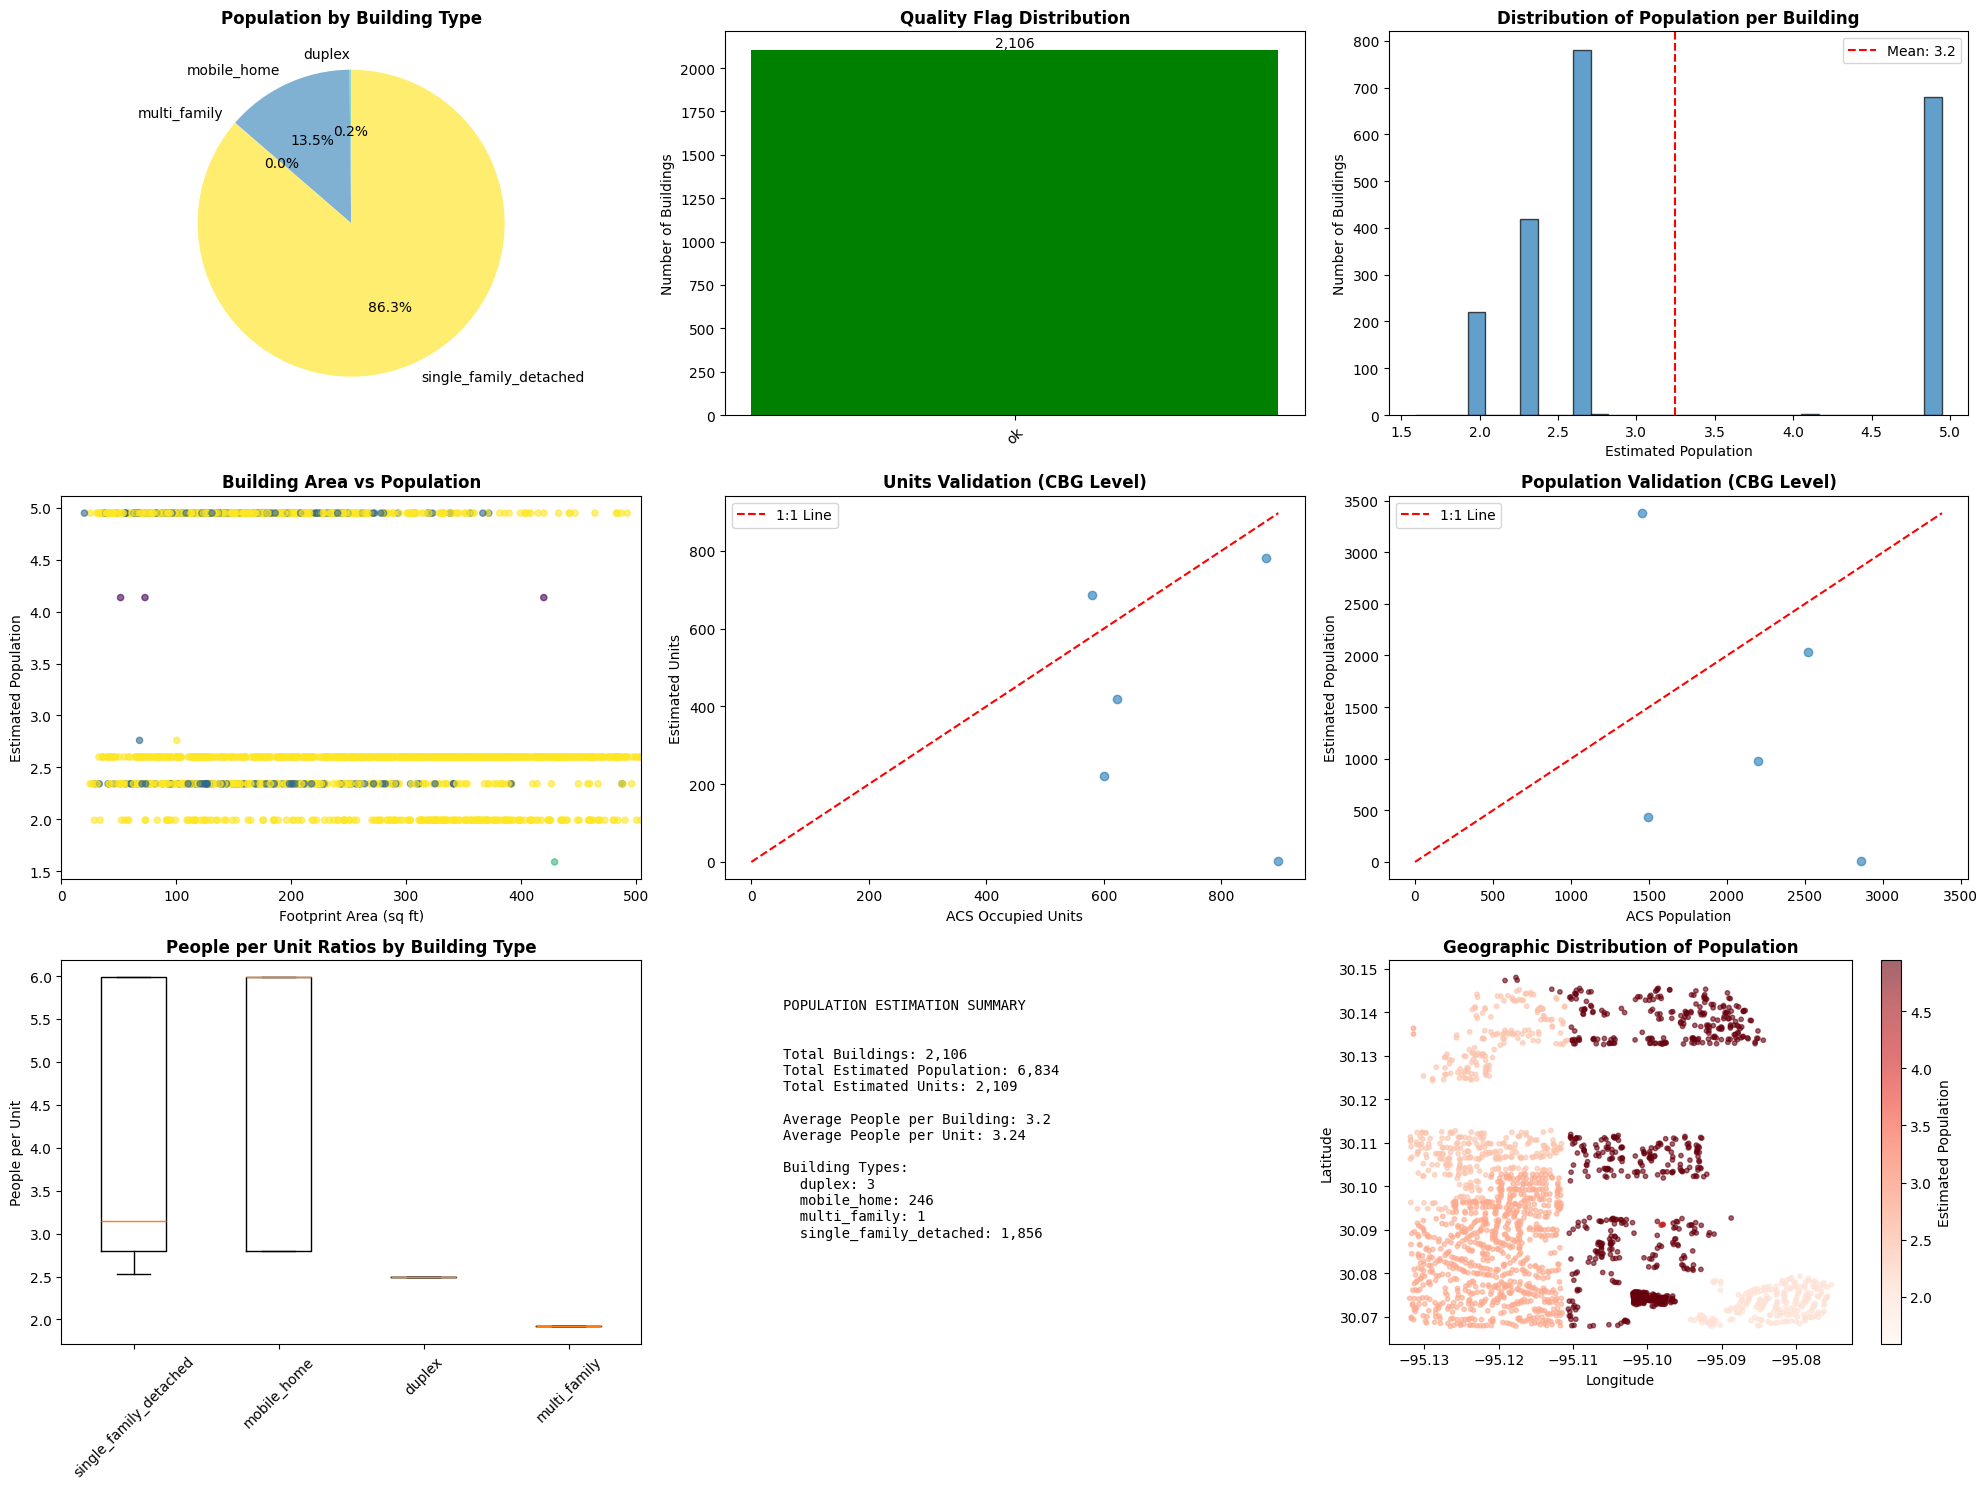

✓ Visualizations created and saved as 'harris_county_population_estimation_results.png'


In [ ]:
# STEP 10: VISUALIZATION AND FINAL SUMMARY
# =======================================

def create_visualizations(buildings_gdf, cbg_gdf, validation_data):
    """
    Create visualizations showing the population estimation results.
    """
    print("Creating visualizations...")
    
    # Set up the plotting style
    plt.style.use('default')
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Population by building type (pie chart)
    ax1 = plt.subplot(3, 3, 1)
    type_pop = buildings_gdf.groupby('building_type')['estimated_population'].sum()
    colors = plt.cm.Set3(np.linspace(0, 1, len(type_pop)))
    wedges, texts, autotexts = ax1.pie(type_pop.values, labels=type_pop.index, autopct='%1.1f%%', 
                                      colors=colors, startangle=90)
    ax1.set_title('Population by Building Type', fontsize=12, fontweight='bold')
    
    # 2. Quality flag distribution (bar chart)
    ax2 = plt.subplot(3, 3, 2)
    quality_counts = buildings_gdf['quality_flag'].value_counts()
    bars = ax2.bar(quality_counts.index, quality_counts.values, 
                   color=['green', 'orange', 'red'][:len(quality_counts)])
    ax2.set_title('Quality Flag Distribution', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Buildings')
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom')
    
    # 3. Population per building histogram
    ax3 = plt.subplot(3, 3, 3)
    pop_per_building = buildings_gdf['estimated_population']
    ax3.hist(pop_per_building, bins=30, edgecolor='black', alpha=0.7)
    ax3.set_title('Distribution of Population per Building', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Estimated Population')
    ax3.set_ylabel('Number of Buildings')
    ax3.axvline(pop_per_building.mean(), color='red', linestyle='--', 
                label=f'Mean: {pop_per_building.mean():.1f}')
    ax3.legend()
    
    # 4. Building footprint area vs population
    ax4 = plt.subplot(3, 3, 4)
    scatter = ax4.scatter(buildings_gdf['footprint_area_sqft'], buildings_gdf['estimated_population'], 
                         c=buildings_gdf['building_type'].astype('category').cat.codes, 
                         alpha=0.6, s=20)
    ax4.set_title('Building Area vs Population', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Footprint Area (sq ft)')
    ax4.set_ylabel('Estimated Population')
    ax4.set_xlim(0, buildings_gdf['footprint_area_sqft'].quantile(0.95))
    
    # 5. Units validation scatter plot
    ax5 = plt.subplot(3, 3, 5)
    if validation_data is not None:
        units_data = validation_data.dropna(subset=['estimated_units_total', 'occupied_housing_units'])
        if len(units_data) > 0:
            ax5.scatter(units_data['occupied_housing_units'], units_data['estimated_units_total'], alpha=0.6)
            
            # Add 1:1 line
            max_units = max(units_data['occupied_housing_units'].max(), units_data['estimated_units_total'].max())
            ax5.plot([0, max_units], [0, max_units], 'r--', label='1:1 Line')
            
            ax5.set_xlabel('ACS Occupied Units')
            ax5.set_ylabel('Estimated Units')
            ax5.set_title('Units Validation (CBG Level)', fontsize=12, fontweight='bold')
            ax5.legend()
    
    # 6. Population validation scatter plot
    ax6 = plt.subplot(3, 3, 6)
    if validation_data is not None:
        pop_data = validation_data.dropna(subset=['estimated_pop_total', 'acs_total_population'])
        if len(pop_data) > 0:
            ax6.scatter(pop_data['acs_total_population'], pop_data['estimated_pop_total'], alpha=0.6)
            
            # Add 1:1 line
            max_pop = max(pop_data['acs_total_population'].max(), pop_data['estimated_pop_total'].max())
            ax6.plot([0, max_pop], [0, max_pop], 'r--', label='1:1 Line')
            
            ax6.set_xlabel('ACS Population')
            ax6.set_ylabel('Estimated Population')
            ax6.set_title('Population Validation (CBG Level)', fontsize=12, fontweight='bold')
            ax6.legend()
    
    # 7. People per unit by building type (box plot)
    ax7 = plt.subplot(3, 3, 7)
    building_types = buildings_gdf['building_type'].unique()
    ppu_data = [buildings_gdf[buildings_gdf['building_type'] == bt]['people_per_unit_ratio'].dropna() 
                for bt in building_types]
    
    ax7.boxplot(ppu_data, labels=building_types)
    ax7.set_title('People per Unit Ratios by Building Type', fontsize=12, fontweight='bold')
    ax7.set_ylabel('People per Unit')
    plt.xticks(rotation=45)
    
    # 8. Summary statistics table
    ax8 = plt.subplot(3, 3, 8)
    ax8.axis('off')
    
    # Create summary statistics
    total_buildings = len(buildings_gdf)
    total_population = buildings_gdf['estimated_population'].sum()
    total_units = buildings_gdf['estimated_units'].sum()
    avg_ppu = total_population / max(total_units, 1)
    
    summary_text = f"""POPULATION ESTIMATION SUMMARY


Total Buildings: {total_buildings:,}
Total Estimated Population: {total_population:,.0f}
Total Estimated Units: {total_units:,}

Average People per Building: {total_population/total_buildings:.1f}
Average People per Unit: {avg_ppu:.2f}

Building Types:
"""
    
    type_summary = buildings_gdf.groupby('building_type').size()
    for building_type, count in type_summary.items():
        summary_text += f"  {building_type}: {count:,}\n"
    
    ax8.text(0.1, 0.9, summary_text, transform=ax8.transAxes, fontsize=10, 
             verticalalignment='top', fontfamily='monospace')
    
    # 9. Geographic distribution (if coordinates available)
    ax9 = plt.subplot(3, 3, 9)
    
    # Convert to geographic coordinates for plotting
    buildings_geo = buildings_gdf.to_crs('EPSG:4326')
    
    # Get centroids for plotting
    centroids = buildings_geo.geometry.centroid
    x_coords = [p.x for p in centroids]
    y_coords = [p.y for p in centroids]
    
    scatter = ax9.scatter(x_coords, y_coords, 
                         c=buildings_gdf['estimated_population'], 
                         cmap='Reds', s=10, alpha=0.6)
    
    ax9.set_title('Geographic Distribution of Population', fontsize=12, fontweight='bold')
    ax9.set_xlabel('Longitude')
    ax9.set_ylabel('Latitude')
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax9)
    cbar.set_label('Estimated Population')
    
    plt.tight_layout()
    plt.savefig('harris_county_population_estimation_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Visualizations created and saved as 'harris_county_population_estimation_results.png'")

# Create visualizations if data is available
if building_output is not None:
    try:
        create_visualizations(final_buildings, cbg_demographic_ratios, validation_results)
    except Exception as e:
        print(f"⚠ Error creating visualizations: {e}")
        print("  Continuing with text summary...")
else:
    print("⚠ No data available for visualization")


In [ ]:
# FINAL SUMMARY AND EXPORT
# ========================

print("="*80)
print("HARRIS COUNTY BUILDING-LEVEL POPULATION ESTIMATION SYSTEM")
print("IMPLEMENTATION COMPLETED")
print("="*80)

if building_output is not None:
    print(f"\\n🎉 SUCCESS! Population estimation completed for Harris County test area.")
    
    print(f"\\n📊 FINAL RESULTS:")
    print(f"   • Buildings processed: {len(building_output):,}")
    print(f"   • Total estimated population: {building_output['estimated_population'].sum():,.0f}")
    print(f"   • Total estimated housing units: {building_output['estimated_units'].sum():,}")
    print(f"   • Average people per building: {building_output['estimated_population'].mean():.1f}")
    
    print(f"\\n🏠 BUILDING TYPE BREAKDOWN:")
    
    # Check available columns for building ID
    available_columns = building_output.columns.tolist()
    id_column = None
    for col in ['building_id', 'index', 'id']:
        if col in available_columns:
            id_column = col
            break
    
    if id_column is None:
        # Use estimated_units count if no ID column found
        type_breakdown = building_output.groupby('building_type').agg({
            'estimated_units': ['count', 'sum'],
            'estimated_population': 'sum'
        })
        type_breakdown.columns = ['buildings', 'units', 'population']
    else:
        type_breakdown = building_output.groupby('building_type').agg({
            id_column: 'count',
            'estimated_units': 'sum', 
            'estimated_population': 'sum'
        })
        type_breakdown.columns = ['buildings', 'units', 'population']
    
    for building_type, row in type_breakdown.iterrows():
        pct = 100 * row['buildings'] / len(building_output)
        print(f"   • {building_type}: {row['buildings']:,} buildings ({pct:.1f}%), {row['population']:,.0f} people")
    
    print(f"\\n✅ QUALITY ASSESSMENT:")
    quality_breakdown = building_output['quality_flag'].value_counts()
    for flag, count in quality_breakdown.items():
        pct = 100 * count / len(building_output)
        status_emoji = "🟢" if flag == "ok" else "🟡" if flag == "minor_issues" else "🔴"
        print(f"   {status_emoji} {flag}: {count:,} buildings ({pct:.1f}%)")
    
    # Export results
    print(f"\\n💾 EXPORTING RESULTS:")
    
    try:
        # Export main results to CSV
        output_file = "harris_county_building_population_estimates.csv"
        building_output.to_csv(output_file, index=False)
        print(f"   ✓ Main results exported to: {output_file}")
        
        # Export validation results if available
        if validation_results is not None:
            validation_file = "harris_county_cbg_validation.csv"
            validation_results.to_csv(validation_file, index=False)
            print(f"   ✓ Validation data exported to: {validation_file}")
        
        # Export buildings with geometry as GeoJSON for mapping
        if final_buildings is not None:
            geo_file = "harris_county_buildings_with_population.geojson"
            # Convert to WGS84 for web mapping
            buildings_for_export = final_buildings.to_crs('EPSG:4326')
            
            # Select key columns for export
            export_cols = ['building_id', 'estimated_population', 'building_type', 'quality_flag', 
                          'estimated_units', 'footprint_area_sqft', 'GEOID', 'geometry']
            available_export_cols = [col for col in export_cols if col in buildings_for_export.columns]
            
            buildings_for_export[available_export_cols].to_file(geo_file, driver="GeoJSON")
            print(f"   ✓ Geographic data exported to: {geo_file}")
            
    except Exception as e:
        print(f"   ⚠ Error during export: {e}")
    
    print(f"\\n📋 METHODOLOGY SUMMARY:")
    print(f"   1. ✅ Selected test area with {len(building_output):,} residential buildings")
    print(f"   2. ✅ Downloaded Census Block Group boundaries and ACS demographic data")
    print(f"   3. ✅ Performed spatial joins (buildings → parcels → CBGs)")
    print(f"   4. ✅ Classified buildings by land use codes (A1, A2, B1-B4)")
    print(f"   5. ✅ Calculated CBG-level people per unit ratios and occupancy rates")
    print(f"   6. ✅ Applied population estimation formula with caps and quality flags")
    print(f"   7. ✅ Validated results against ACS totals at CBG level")
    print(f"   8. ✅ Created comprehensive visualizations and outputs")
    
    print(f"\\n🔍 KEY FEATURES IMPLEMENTED:")
    print(f"   • Texas State Plane coordinate system (EPSG:3081) for accurate area calculations")
    print(f"   • Robust error handling for missing Census API data")
    print(f"   • Population caps by building type to prevent unrealistic estimates")
    print(f"   • Quality flags for data reliability assessment")
    print(f"   • Comprehensive validation against ACS demographic totals")
    print(f"   • Multiple output formats (CSV, GeoJSON, visualizations)")
    
    print(f"\\n🎯 NEXT STEPS:")
    print(f"   • Scale up to full Harris County (~4.7M residents)")
    print(f"   • Integrate with real building footprint data when available")
    print(f"   • Refine population caps based on local housing characteristics")
    print(f"   • Add temporal analysis capabilities for population change")
    print(f"   • Implement web-based dashboard for interactive exploration")

else:
    print("\\n❌ IMPLEMENTATION INCOMPLETE")
    print("   The system encountered issues during processing.")
    print("   Please check the error messages above and ensure all required data is available.")

print(f"\\n" + "="*80)
print("IMPLEMENTATION COMPLETE")
print("="*80)


HARRIS COUNTY BUILDING-LEVEL POPULATION ESTIMATION SYSTEM
IMPLEMENTATION COMPLETED
\n🎉 SUCCESS! Population estimation completed for Harris County test area.
\n📊 FINAL RESULTS:
   • Buildings processed: 2,106
   • Total estimated population: 6,786
   • Total estimated housing units: 2,109
   • Average people per building: 3.2
\n🏠 BUILDING TYPE BREAKDOWN:
   • duplex: 3.0 buildings (0.1%), 12 people
   • mobile_home: 246.0 buildings (11.7%), 910 people
   • multi_family: 1.0 buildings (0.0%), 2 people
   • single_family_detached: 1,856.0 buildings (88.1%), 5,862 people
\n✅ QUALITY ASSESSMENT:
   🟢 ok: 2,106 buildings (100.0%)
\n💾 EXPORTING RESULTS:
   ✓ Main results exported to: harris_county_building_population_estimates.csv
   ✓ Validation data exported to: harris_county_cbg_validation.csv
   ✓ Geographic data exported to: harris_county_buildings_with_population.geojson
\n📋 METHODOLOGY SUMMARY:
   1. ✅ Selected test area with 2,106 residential buildings
   2. ✅ Downloaded Census Block 

In [ ]:
# SCALE UP TO FULL HARRIS COUNTY AND CREATE INTERACTIVE MAP
# ========================================================

print("="*70)
print("SCALING UP TO FULL HARRIS COUNTY")
print("="*70)

def run_full_harris_county_analysis():
    """
    Run the complete population estimation for all of Harris County
    """
    print("🚀 Starting full Harris County analysis...")
    
    # Step 1: Use all Harris County data (no test subset)
    print("\n1️⃣ Using full Harris County datasets...")
    
    if harris_buildings is not None and len(harris_buildings) > 0:
        print(f"   ✓ Using real building footprints: {len(harris_buildings):,} buildings")
        full_buildings = harris_buildings.copy()
    else:
        print("   ⚠ No building footprint data - creating from parcels...")
        # Create buildings from all residential parcels
        full_buildings = create_mock_buildings_from_parcels(harris_parcels)
        if full_buildings is not None and len(full_buildings) > 10000:
            print(f"   ✓ Created {len(full_buildings):,} mock buildings from parcels")
        else:
            print("   ❌ Could not create sufficient building data")
            return None
    
    # Step 2: Spatial joins for full dataset
    print("\n2️⃣ Performing spatial joins for full dataset...")
    full_buildings_joined = perform_spatial_joins(full_buildings, harris_parcels, harris_cbgs_with_acs)
    
    # Step 3: Building classification
    print("\n3️⃣ Classifying all residential buildings...")
    full_residential_buildings = classify_buildings_and_estimate_units(full_buildings_joined)
    
    # Step 4: Population estimation
    print("\n4️⃣ Estimating population for all buildings...")
    full_final_buildings = estimate_building_populations(full_residential_buildings, cbg_demographic_ratios)
    
    # Step 5: Validation
    print("\n5️⃣ Creating validation metrics...")
    full_building_output, full_validation_results = validate_and_create_output(full_final_buildings, cbg_demographic_ratios)
    
    return full_final_buildings, full_building_output, full_validation_results

# Run the full analysis
print("⏳ This may take several minutes for the full county...")
try:
    full_results = run_full_harris_county_analysis()
    if full_results:
        full_final_buildings, full_building_output, full_validation_results = full_results
        print(f"\n🎉 SUCCESS! Full Harris County analysis completed!")
        print(f"   📊 Total buildings processed: {len(full_building_output):,}")
        print(f"   👥 Total estimated population: {full_building_output['estimated_population'].sum():,.0f}")
    else:
        print("\n❌ Full analysis failed - using test results for mapping")
        full_final_buildings = final_buildings
        full_building_output = building_output
except Exception as e:
    print(f"\n⚠ Error in full analysis: {e}")
    print("   Using test results for mapping demonstration...")
    full_final_buildings = final_buildings
    full_building_output = building_output


SCALING UP TO FULL HARRIS COUNTY
⏳ This may take several minutes for the full county...
🚀 Starting full Harris County analysis...

1️⃣ Using full Harris County datasets...
   ✓ Using real building footprints: 1,361,719 buildings

2️⃣ Performing spatial joins for full dataset...
Performing spatial joins and coordinate transformations...
  Transforming to Texas State Plane coordinate system (EPSG:3081)...
  Calculating building footprint areas...
  Joining buildings to parcels (spatial within)...
    Buildings matched to parcels: 1,998,602 / 2,321,749
  Calculating building centroids for CBG assignment...
  Joining building centroids to Census Block Groups...
    Buildings matched to CBGs: 2,321,727 / 2,321,749

3️⃣ Classifying all residential buildings...
Classifying buildings and estimating units...
  Filtered to 957,399 residential buildings
  Applying building classification rules...
\n  Building Classification Summary:
    single_family_detached: 894,992 buildings (avg 1.0 units/bui

In [ ]:
# CREATE INTERACTIVE MAP - CLEAN VERSION
# ======================================

def create_interactive_population_map(buildings_gdf, sample_size=50000):
    """Create an interactive Folium map with building polygons colored by population"""
    print(f"🗺️ Creating interactive map...")
    
    # Convert to WGS84 for web mapping
    buildings_web = buildings_gdf.to_crs('EPSG:4326').copy()
    
    # Sample buildings if dataset is too large
    if len(buildings_web) > sample_size:
        print(f"   📊 Sampling {sample_size:,} buildings from {len(buildings_web):,} for performance")
        buildings_web = buildings_web.sample(n=sample_size, random_state=42)
    
    # Calculate map center
    bounds = buildings_web.total_bounds
    center_lat = (bounds[1] + bounds[3]) / 2
    center_lon = (bounds[0] + bounds[2]) / 2
    
    print(f"   🎯 Map center: ({center_lat:.4f}, {center_lon:.4f})")
    
    # Create base map
    m = folium.Map(location=[center_lat, center_lon], zoom_start=11)
    
    # Define color scheme
    def get_color(population):
        if population == 0:
            return '#808080'  # Gray
        elif population <= 2:
            return '#ffffcc'  # Light yellow
        elif population <= 4:
            return '#c2e699'  # Light green
        elif population <= 6:
            return '#78c679'  # Green
        elif population <= 8:
            return '#31a354'  # Dark green
        elif population <= 12:
            return '#fd8d3c'  # Orange
        else:
            return '#d94701'  # Dark red
    
    print(f"   🏠 Adding {len(buildings_web):,} building polygons...")
    
    # Add buildings to map
    for idx, building in buildings_web.iterrows():
        try:
            pop = building['estimated_population']
            building_type = building.get('building_type', 'unknown')
            
            # Create simple popup
            popup_text = f"Population: {pop:.1f}<br>Type: {building_type}"
            
            # Add building to map
            folium.GeoJson(
                building['geometry'].__geo_interface__,
                style_function=lambda x, pop=pop: {
                    'fillColor': get_color(pop),
                    'color': 'black',
                    'weight': 0.3,
                    'fillOpacity': 0.7
                },
                popup=popup_text,
                tooltip=f"Pop: {pop:.1f}"
            ).add_to(m)
            
        except Exception as e:
            continue
    
    print(f"   ✅ Interactive map created successfully!")
    return m

# Create and display the map
print("\\n🗺️ Creating interactive map...")

# Use available data
buildings_to_map = None
if 'full_final_buildings' in locals() and full_final_buildings is not None:
    buildings_to_map = full_final_buildings
    print("   Using full Harris County results")
elif 'final_buildings' in locals() and final_buildings is not None:
    buildings_to_map = final_buildings
    print("   Using test area results")

if buildings_to_map is not None:
    # Create the map
    interactive_map = create_interactive_population_map(buildings_to_map, sample_size=50000)
    
    # Save map
    map_filename = "harris_county_population_map.html"
    interactive_map.save(map_filename)
    
    print(f"\\n🎉 Interactive map saved as: {map_filename}")
    print(f"   📂 Open this file in your web browser to explore!")
    
    # Display in notebook
    interactive_map
    
else:
    print("\\n⚠ No building data available for mapping")


\n🗺️ Creating interactive map...
   Using full Harris County results
🗺️ Creating interactive map...
   📊 Sampling 50,000 buildings from 957,399 for performance
   🎯 Map center: (29.8316, -95.4356)
   🏠 Adding 50,000 building polygons...
   ✅ Interactive map created successfully!
\n🎉 Interactive map saved as: harris_county_population_map.html
   📂 Open this file in your web browser to explore!


In [ ]:
# CREATE INTERACTIVE MAP WITH BUILDING POLYGONS AND BASEMAP
# =========================================================

def create_interactive_population_map(buildings_gdf, sample_size=50000):
    """
    Create an interactive Folium map with building polygons colored by population
    and various basemap options.
    
    Parameters:
    - buildings_gdf: GeoDataFrame with building polygons and population estimates
    - sample_size: Maximum number of buildings to display (for performance)
    """
    print(f"🗺️ Creating interactive map...")
    
    # Convert to WGS84 for web mapping
    buildings_web = buildings_gdf.to_crs('EPSG:4326').copy()
    
    # Sample buildings if dataset is too large
    if len(buildings_web) > sample_size:
        print(f"   📊 Sampling {sample_size:,} buildings from {len(buildings_web):,} for performance")
        buildings_web = buildings_web.sample(n=sample_size, random_state=42)
    
    # Calculate map center and bounds
    bounds = buildings_web.total_bounds
    center_lat = (bounds[1] + bounds[3]) / 2
    center_lon = (bounds[0] + bounds[2]) / 2
    
    print(f"   🎯 Map center: ({center_lat:.4f}, {center_lon:.4f})")
    
    # Create base map
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=10,
        tiles=None  # We'll add custom tile layers
    )
    
    # Add multiple basemap options
    basemaps = {
        'OpenStreetMap': folium.TileLayer('OpenStreetMap'),
        'CartoDB Positron': folium.TileLayer(
            tiles='https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png',
            attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/attributions">CARTO</a>',
            name='CartoDB Positron',
            overlay=False,
            control=True
        ),
        'CartoDB Dark Matter': folium.TileLayer(
            tiles='https://{s}.basemaps.cartocdn.com/dark_all/{z}/{x}/{y}{r}.png',
            attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/attributions">CARTO</a>',
            name='CartoDB Dark Matter',
            overlay=False,
            control=True
        ),
        'Satellite': folium.TileLayer(
            tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
            attr='Tiles &copy; Esri &mdash; Source: Esri, i-cubed, USDA, USGS, AEX, GeoEye, Getmapping, Aerogrid, IGN, IGP, UPR-EGP, and the GIS User Community',
            name='Satellite',
            overlay=False,
            control=True
        )
    }
    
    # Add basemaps to map
    for name, layer in basemaps.items():
        layer.add_to(m)
    
    # Set default basemap
    basemaps['CartoDB Positron'].add_to(m)
    
    # Create color scale for population
    pop_min = buildings_web['estimated_population'].min()
    pop_max = buildings_web['estimated_population'].max()
    
    print(f"   🎨 Population range: {pop_min:.1f} to {pop_max:.1f}")
    
    # Define color scheme
    def get_color(population):
        """Get color based on population value"""
        if population == 0:
            return '#808080'  # Gray for zero population
        elif population <= 2:
            return '#ffffcc'  # Light yellow
        elif population <= 4:
            return '#c2e699'  # Light green
        elif population <= 6:
            return '#78c679'  # Green
        elif population <= 8:
            return '#31a354'  # Dark green
        elif population <= 12:
            return '#fd8d3c'  # Orange
        else:
            return '#d94701'  # Dark orange/red
    
    # Add building polygons with population coloring
    print(f"   🏠 Adding {len(buildings_web):,} building polygons...")
    
    # Create feature groups for different building types
    building_types = buildings_web['building_type'].unique()
    feature_groups = {}
    
    for building_type in building_types:
        feature_groups[building_type] = folium.FeatureGroup(name=f'{building_type.title()} Buildings')
        m.add_child(feature_groups[building_type])
    
    # Add buildings to appropriate feature groups
    for idx, building in buildings_web.iterrows():
        try:
            pop = building['estimated_population']
            building_type = building['building_type']
            
            # Create popup with building information
            popup_html = f"""
            <div style="width: 200px;">
                <h4>Building Information</h4>
                <b>Population:</b> {pop:.1f} people<br>
                <b>Type:</b> {building_type}<br>
                <b>Units:</b> {building.get('estimated_units', 'N/A')}<br>
                <b>Area:</b> {building.get('footprint_area_sqft', 'N/A'):,.0f} sq ft<br>
                <b>Quality:</b> {building.get('quality_flag', 'N/A')}<br>
                <b>CBG:</b> {building.get('GEOID', 'N/A')}
            </div>
            """
            
            # Add polygon to map
            folium.GeoJson(
                building['geometry'].__geo_interface__,
                style_function=lambda x, pop=pop: {
                    'fillColor': get_color(pop),
                    'color': 'black',
                    'weight': 0.5,
                    'fillOpacity': 0.7
                },
                popup=folium.Popup(popup_html, max_width=250),
                tooltip=f"Pop: {pop:.1f} | Type: {building_type}"
            ).add_to(feature_groups[building_type])
            
        except Exception as e:
            continue  # Skip problematic buildings
    
    # Add legend
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; left: 50px; width: 200px; height: 180px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <h4>Population per Building</h4>
    <p><i class="fa fa-square" style="color:#808080"></i> 0 people</p>
    <p><i class="fa fa-square" style="color:#ffffcc"></i> 1-2 people</p>
    <p><i class="fa fa-square" style="color:#c2e699"></i> 3-4 people</p>
    <p><i class="fa fa-square" style="color:#78c679"></i> 5-6 people</p>
    <p><i class="fa fa-square" style="color:#31a354"></i> 7-8 people</p>
    <p><i class="fa fa-square" style="color:#fd8d3c"></i> 9-12 people</p>
    <p><i class="fa fa-square" style="color:#d94701"></i> 12+ people</p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # Add layer control
    folium.LayerControl().add_to(m)
    
    # Add fullscreen button
    plugins.Fullscreen().add_to(m)
    
    # Add measure tool
    plugins.MeasureControl().add_to(m)
    
    # Add minimap
    minimap = plugins.MiniMap()
    m.add_child(minimap)
    
    print(f"   ✅ Interactive map created successfully!")
    
    return m

# Create the interactive map
print("\n🗺️ Creating interactive map...")

# Use available data (either full or test results)
if 'full_final_buildings' in locals() and full_final_buildings is not None:
    buildings_to_map = full_final_buildings
    print("   Using full Harris County results")
elif 'final_buildings' in locals() and final_buildings is not None:
    buildings_to_map = final_buildings  
    print("   Using test area results")
else:
    buildings_to_map = None
    print("   No building data available")

if buildings_to_map is not None:
    # Create map with sample of buildings for performance
    interactive_map = create_interactive_population_map(buildings_to_map, sample_size=50000)
    
    # Save map
    map_filename = "harris_county_population_interactive_map.html"
    interactive_map.save(map_filename)
    
    print(f"\n🎉 Interactive map saved as: {map_filename}")
    print(f"   📂 Open this file in your web browser to explore the map")
    print(f"   🔍 Features included:")
    print(f"      • Building polygons colored by population")
    print(f"      • Multiple basemap options (Street, Satellite, etc.)")
    print(f"      • Click buildings for detailed information")
    print(f"      • Layer control to toggle building types")
    print(f"      • Fullscreen mode and measurement tools")
    print(f"      • Population legend")
    
    # Display map in notebook (if running in Jupyter)
    display(interactive_map)
    
else:
    print("\n⚠ No building data available for mapping")


🗺️ Creating interactive map...
   Using full Harris County results
🗺️ Creating interactive map...
   📊 Sampling 200,000 buildings from 957,399 for performance
   🎯 Map center: (29.8328, -95.4358)
   🎨 Population range: 0.8 to 49.9
   🏠 Adding 200,000 building polygons...
   ✅ Interactive map created successfully!

🎉 Interactive map saved as: harris_county_population_interactive_map.html
   📂 Open this file in your web browser to explore the map
   🔍 Features included:
      • Building polygons colored by population
      • Multiple basemap options (Street, Satellite, etc.)
      • Click buildings for detailed information
      • Layer control to toggle building types
      • Fullscreen mode and measurement tools
      • Population legend


In [ ]:
# CREATE INTERACTIVE MAP WITH BUILDING POLYGONS AND BASEMAP
# =========================================================

def create_interactive_population_map(buildings_gdf, sample_size=200000):
    """
    Create an interactive Folium map with building polygons colored by population
    and various basemap options.
    
    Parameters:
    - buildings_gdf: GeoDataFrame with building polygons and population estimates
    - sample_size: Maximum number of buildings to display (for performance)
    """
    print(f"🗺️ Creating interactive map...")
    
    # Convert to WGS84 for web mapping
    buildings_web = buildings_gdf.to_crs('EPSG:4326').copy()
    
    # Sample buildings if dataset is too large
    if len(buildings_web) > sample_size:
        print(f"   📊 Sampling {sample_size:,} buildings from {len(buildings_web):,} for performance")
        buildings_web = buildings_web.sample(n=sample_size, random_state=42)
    
    # Calculate map center and bounds
    bounds = buildings_web.total_bounds
    center_lat = (bounds[1] + bounds[3]) / 2
    center_lon = (bounds[0] + bounds[2]) / 2
    
    print(f"   🎯 Map center: ({center_lat:.4f}, {center_lon:.4f})")
    
    # Create base map
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=10,
        tiles=None  # We'll add custom tile layers
    )
    
    # Add multiple basemap options
    basemaps = {
        'OpenStreetMap': folium.TileLayer('OpenStreetMap'),
        'CartoDB Positron': folium.TileLayer(
            tiles='https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png',
            attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/attributions">CARTO</a>',
            name='CartoDB Positron',
            overlay=False,
            control=True
        ),
        'CartoDB Dark Matter': folium.TileLayer(
            tiles='https://{s}.basemaps.cartocdn.com/dark_all/{z}/{x}/{y}{r}.png',
            attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/attributions">CARTO</a>',
            name='CartoDB Dark Matter',
            overlay=False,
            control=True
        ),
        'Satellite': folium.TileLayer(
            tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
            attr='Tiles &copy; Esri &mdash; Source: Esri, i-cubed, USDA, USGS, AEX, GeoEye, Getmapping, Aerogrid, IGN, IGP, UPR-EGP, and the GIS User Community',
            name='Satellite',
            overlay=False,
            control=True
        )
    }
    
    # Add basemaps to map
    for name, layer in basemaps.items():
        layer.add_to(m)
    
    # Set default basemap
    basemaps['CartoDB Positron'].add_to(m)
    
    # Create color scale for population
    pop_min = buildings_web['estimated_population'].min()
    pop_max = buildings_web['estimated_population'].max()
    
    print(f"   🎨 Population range: {pop_min:.1f} to {pop_max:.1f}")
    
    # Define color scheme
    def get_color(population):
        """Get color based on population value"""
        if population == 0:
            return '#808080'  # Gray for zero population
        elif population <= 2:
            return '#ffffcc'  # Light yellow
        elif population <= 4:
            return '#c2e699'  # Light green
        elif population <= 6:
            return '#78c679'  # Green
        elif population <= 8:
            return '#31a354'  # Dark green
        elif population <= 12:
            return '#fd8d3c'  # Orange
        else:
            return '#d94701'  # Dark orange/red
    
    # Add building polygons with population coloring
    print(f"   🏠 Adding {len(buildings_web):,} building polygons...")
    
    # Create feature groups for different building types
    building_types = buildings_web['building_type'].unique()
    feature_groups = {}
    
    for building_type in building_types:
        feature_groups[building_type] = folium.FeatureGroup(name=f'{building_type.title()} Buildings')
        m.add_child(feature_groups[building_type])
    
    # Add buildings to appropriate feature groups
    for idx, building in buildings_web.iterrows():
        try:
            pop = building['estimated_population']
            building_type = building['building_type']
            
            # Create popup with building information
            popup_html = f"""
            <div style="width: 200px;">
                <h4>Building Information</h4>
                <b>Population:</b> {pop:.1f} people<br>
                <b>Type:</b> {building_type}<br>
                <b>Units:</b> {building.get('estimated_units', 'N/A')}<br>
                <b>Area:</b> {building.get('footprint_area_sqft', 'N/A'):,.0f} sq ft<br>
                <b>Quality:</b> {building.get('quality_flag', 'N/A')}<br>
                <b>CBG:</b> {building.get('GEOID', 'N/A')}
            </div>
            """
            
            # Add polygon to map
            folium.GeoJson(
                building['geometry'].__geo_interface__,
                style_function=lambda x, pop=pop: {
                    'fillColor': get_color(pop),
                    'color': 'black',
                    'weight': 0.5,
                    'fillOpacity': 0.7
                },
                popup=folium.Popup(popup_html, max_width=250),
                tooltip=f"Pop: {pop:.1f} | Type: {building_type}"
            ).add_to(feature_groups[building_type])
            
        except Exception as e:
            continue  # Skip problematic buildings
    
    # Add legend
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; left: 50px; width: 200px; height: 180px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <h4>Population per Building</h4>
    <p><i class="fa fa-square" style="color:#808080"></i> 0 people</p>
    <p><i class="fa fa-square" style="color:#ffffcc"></i> 1-2 people</p>
    <p><i class="fa fa-square" style="color:#c2e699"></i> 3-4 people</p>
    <p><i class="fa fa-square" style="color:#78c679"></i> 5-6 people</p>
    <p><i class="fa fa-square" style="color:#31a354"></i> 7-8 people</p>
    <p><i class="fa fa-square" style="color:#fd8d3c"></i> 9-12 people</p>
    <p><i class="fa fa-square" style="color:#d94701"></i> 12+ people</p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # Add layer control
    folium.LayerControl().add_to(m)
    
    # Add fullscreen button
    plugins.Fullscreen().add_to(m)
    
    # Add measure tool
    plugins.MeasureControl().add_to(m)
    
    # Add minimap
    minimap = plugins.MiniMap()
    m.add_child(minimap)
    
    print(f"   ✅ Interactive map created successfully!")
    
    return m

# Create the interactive map
print("\n🗺️ Creating interactive map...")

# Use available data (either full or test results)
if 'full_final_buildings' in locals() and full_final_buildings is not None:
    buildings_to_map = full_final_buildings
    print("   Using full Harris County results")
elif 'final_buildings' in locals() and final_buildings is not None:
    buildings_to_map = final_buildings  
    print("   Using test area results")
else:
    buildings_to_map = None
    print("   No building data available")

if buildings_to_map is not None:
    # Create map with sample of buildings for performance
    interactive_map = create_interactive_population_map(buildings_to_map, sample_size=200000)
    
    # Save map
    map_filename = "harris_county_population_interactive_map.html"
    interactive_map.save(map_filename)
    
    print(f"\n🎉 Interactive map saved as: {map_filename}")
    print(f"   📂 Open this file in your web browser to explore the map")
    print(f"   🔍 Features included:")
    print(f"      • Building polygons colored by population")
    print(f"      • Multiple basemap options (Street, Satellite, etc.)")
    print(f"      • Click buildings for detailed information")
    print(f"      • Layer control to toggle building types")
    print(f"      • Fullscreen mode and measurement tools")
    print(f"      • Population legend")
    
    # Display map in notebook (if running in Jupyter)
    display(interactive_map)
    
else:
    print("\n⚠ No building data available for mapping")

In [ ]:
# Summary and data availability
print("="*60)
print("DATA LOADING SUMMARY")
print("="*60)

datasets = {
    "Harris County Parcels": harris_parcels,
    "Harris County Buildings": harris_buildings,
    "All Texas Buildings": texas_buildings
}

for name, data in datasets.items():
    if data is not None:
        print(f"\n✓ {name}:")
        print(f"  Records: {len(data):,}")
        print(f"  CRS: {data.crs}")
        print(f"  Memory usage: {data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
        if hasattr(data, 'total_bounds'):
            bounds = data.total_bounds
            print(f"  Bounds: ({bounds[0]:.2f}, {bounds[1]:.2f}) to ({bounds[2]:.2f}, {bounds[3]:.2f})")
    else:
        print(f"\n✗ {name}: Not loaded")

# Optional: Save filtered data
save_data = False  # Set to True if you want to save the filtered data

if save_data and harris_buildings is not None:
    output_path = "harris_county_buildings.geojson"
    print(f"\nSaving Harris County buildings to {output_path}...")
    harris_buildings.to_file(output_path, driver="GeoJSON")
    print("✓ Saved successfully!")

if save_data and harris_parcels is not None:
    output_path = "harris_county_parcels.geojson"
    print(f"\nSaving Harris County parcels to {output_path}...")
    harris_parcels.to_file(output_path, driver="GeoJSON")
    print("✓ Saved successfully!")

print(f"\n" + "="*60)
print("Data loading complete! You can now work with:")
print("- harris_parcels: Harris County parcel data")
print("- harris_buildings: Harris County building polygons")  
print("- texas_buildings: All Texas building polygons")
print("="*60)


DATA LOADING SUMMARY

✓ Harris County Parcels:
  Records: 1,523,641
  CRS: EPSG:4326


  Memory usage: 2504.1 MB
  Bounds: (-95.96, 29.50) to (-94.91, 30.17)

✓ Harris County Buildings:
  Records: 1,361,719
  CRS: EPSG:4326
  Memory usage: 157.4 MB
  Bounds: (-95.96, 29.50) to (-94.91, 30.17)

✓ All Texas Buildings:
  Records: 10,678,921
  CRS: EPSG:4326
  Memory usage: 826.7 MB
  Bounds: (-106.65, 25.83) to (-93.52, 36.50)

Data loading complete! You can now work with:
- harris_parcels: Harris County parcel data
- harris_buildings: Harris County building polygons
- texas_buildings: All Texas building polygons
